In [ ]:
import pandas as pd
import numpy as np

# Đọc file (bạn dùng 1 trong 2 file csv là được)
df = pd.read_csv("pima-indians-diabetes.csv")

# Đặt lại tên cột nếu file không có header
df.columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

print("=== Dữ liệu ban đầu ===")
print(df.head())

# -----------------------
# 1. Thay giá trị 0 -> NaN
# -----------------------
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)

# -----------------------
# 2. Điền giá trị thiếu bằng mean
# -----------------------
for col in cols_with_zero:
    df[col] = df[col].fillna(df[col].mean())

# -----------------------
# 3. Kiểm tra dữ liệu
# -----------------------
print("\n=== Sau khi xử lý ===")
print(df.isnull().sum())

# -----------------------
# 4. Loại bỏ dữ liệu trùng (nếu có)
# -----------------------
df.drop_duplicates(inplace=True)

# -----------------------
# 5. Chuẩn hóa dữ liệu (Scaling)
# -----------------------
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_scaled = scaler.fit_transform(X)
print("\n=== Dữ liệu đã chuẩn hóa ===")
print(X_scaled[:5])

=== Dữ liệu ban đầu ===
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            1       85             66             29        0  26.6   
1            8      183             64              0        0  23.3   
2            1       89             66             23       94  28.1   
3            0      137             40             35      168  43.1   
4            5      116             74              0        0  25.6   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.351   31        0  
1                     0.672   32        1  
2                     0.167   21        0  
3                     2.288   33        1  
4                     0.201   30        0  

=== Sau khi xử lý ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome         

### Biểu Đồ Histogram

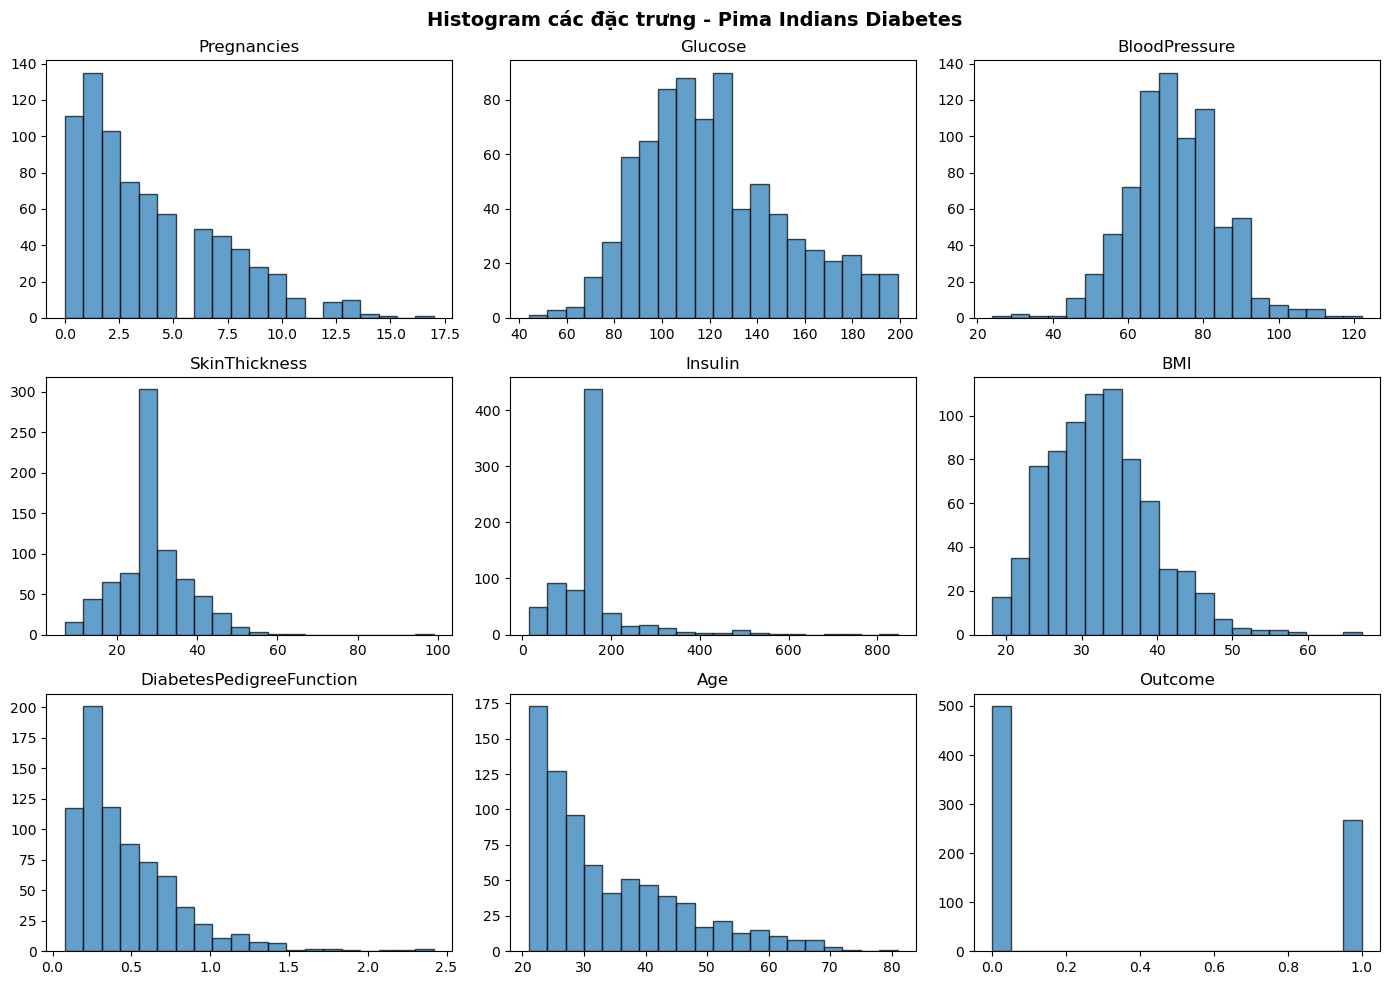

In [2]:
import matplotlib.pyplot as plt

# -----------------------
# Vẽ Histogram cho tất cả các cột
# -----------------------
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

cols = df.columns.tolist()  # tất cả 9 cột

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=20, color='#1f77b4', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=12)
   

plt.suptitle("Histogram các đặc trưng - Pima Indians Diabetes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Biểu đồ Boxplot

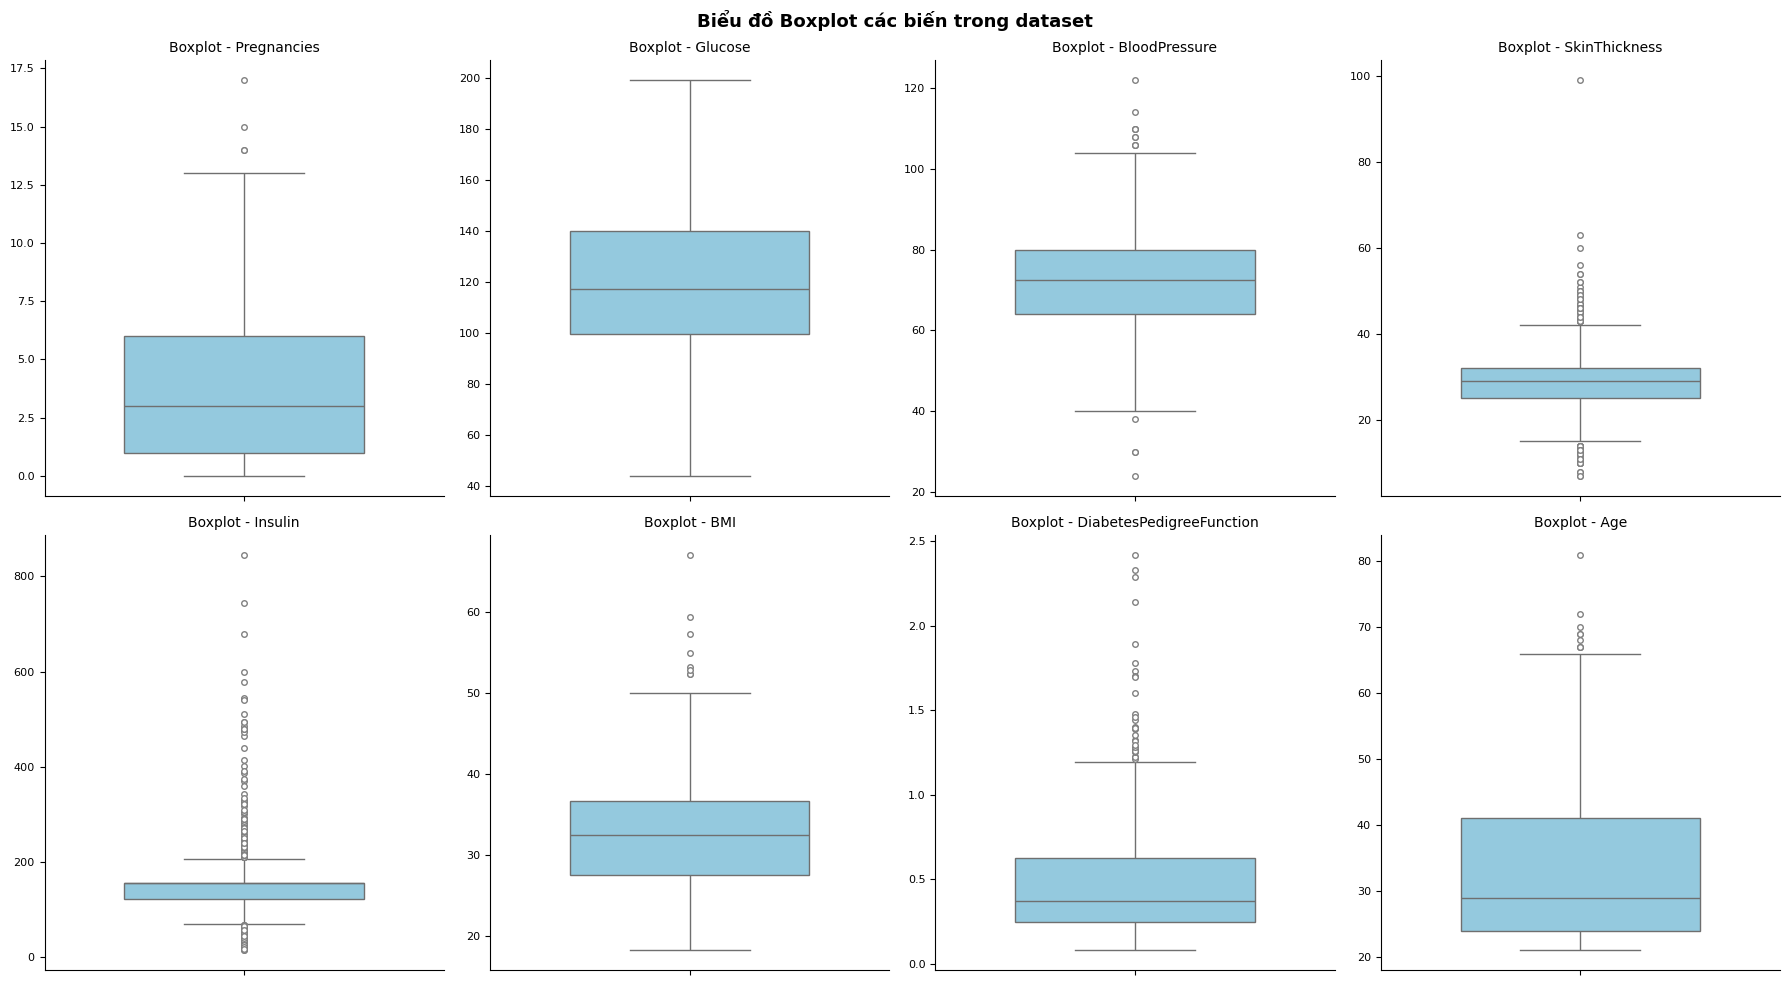

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [col for col in df.columns if col != "Outcome"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df[col].dropna(), ax=axes[i],
                color='#87CEEB',
                width=0.6,          
                linewidth=1,
                flierprops=dict(marker='o', markerfacecolor='white',
                               markeredgecolor='gray', markersize=4))

    axes[i].set_title(f"Boxplot - {col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].tick_params(axis='both', labelsize=8)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle("Biểu đồ Boxplot các biến trong dataset",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Biểu đồ tỉ lệ

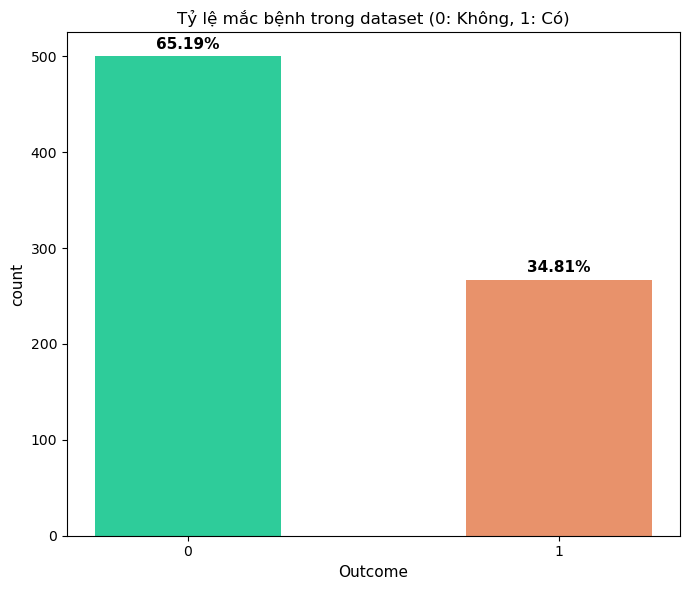

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính số lượng và phần trăm
counts = df["Outcome"].value_counts().sort_index()
percentages = df["Outcome"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(7, 6))

# Vẽ bar chart
colors = ['#2ecc9a', '#e8926b']  # xanh lá + cam như hình
bars = ax.bar(counts.index, counts.values, color=colors, width=0.5)

# Thêm % lên đầu mỗi cột
for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f'{pct:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Tỷ lệ mắc bệnh trong dataset (0: Không, 1: Có)", fontsize=12)
ax.set_xlabel("Outcome", fontsize=11)
ax.set_ylabel("count", fontsize=11)
ax.set_xticks([0, 1])

plt.tight_layout()
plt.show()

### Biểu đồ đặc điểm nhóm bệnh nhân và nhóm khỏe mạnh 

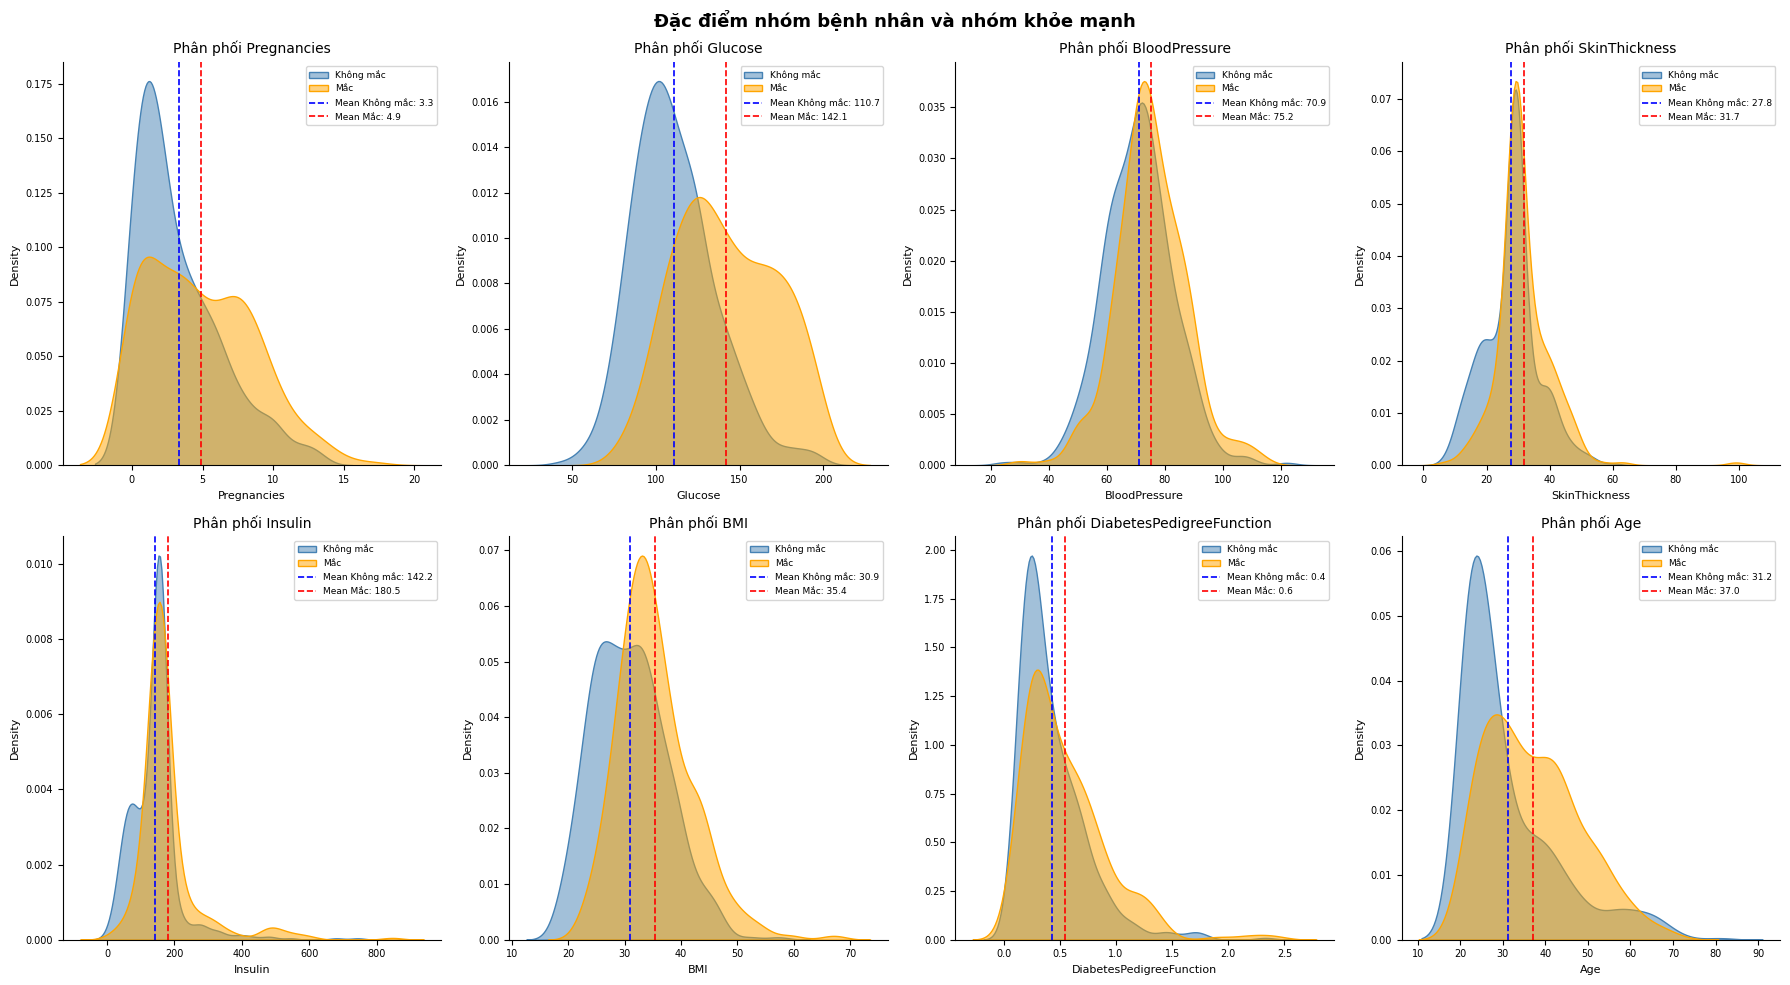

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [col for col in df.columns if col != "Outcome"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    # Tách 2 nhóm
    group0 = df[df["Outcome"] == 0][col]
    group1 = df[df["Outcome"] == 1][col]

    mean0 = group0.mean()
    mean1 = group1.mean()

    # Vẽ KDE cho 2 nhóm
    sns.kdeplot(group0, ax=axes[i], color='steelblue', fill=True, alpha=0.5, label='Không mắc')
    sns.kdeplot(group1, ax=axes[i], color='orange', fill=True, alpha=0.5, label='Mắc')

    # Vẽ đường mean
    axes[i].axvline(mean0, color='blue', linestyle='--', linewidth=1.2)
    axes[i].axvline(mean1, color='red', linestyle='--', linewidth=1.2)

    # Tiêu đề và legend
    axes[i].set_title(f"Phân phối {col}", fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel("Density", fontsize=8)
    axes[i].tick_params(axis='both', labelsize=7)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    # Legend có mean
    axes[i].legend(
        labels=[
            'Không mắc',
            'Mắc',
            f'Mean Không mắc: {mean0:.1f}',
            f'Mean Mắc: {mean1:.1f}'
        ],
        fontsize=6.5,
        loc='upper right'
    )

plt.suptitle("Đặc điểm nhóm bệnh nhân và nhóm khỏe mạnh",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Biểu đồ phân bố bệnh theo độ tuổi

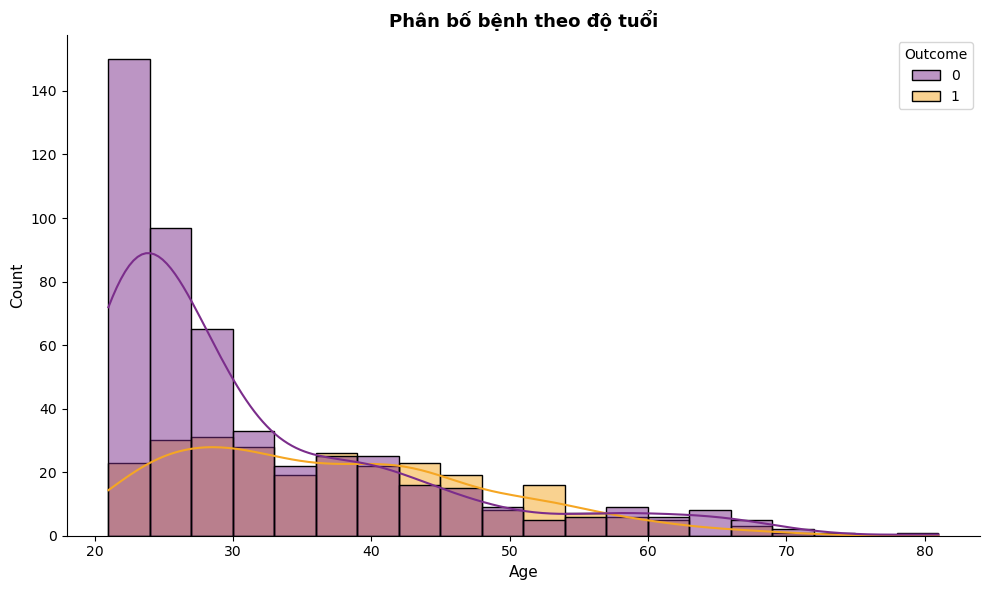

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(data=df, x="Age", hue="Outcome",
             bins=20, kde=True,
             palette={0: '#7B2D8B', 1: '#F5A623'},  # tím + vàng cam
             alpha=0.5, ax=ax)

ax.set_title("Phân bố bệnh theo độ tuổi", fontsize=13, fontweight='bold')
ax.set_xlabel("Age", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Biểu đồ BMI theo tuổi

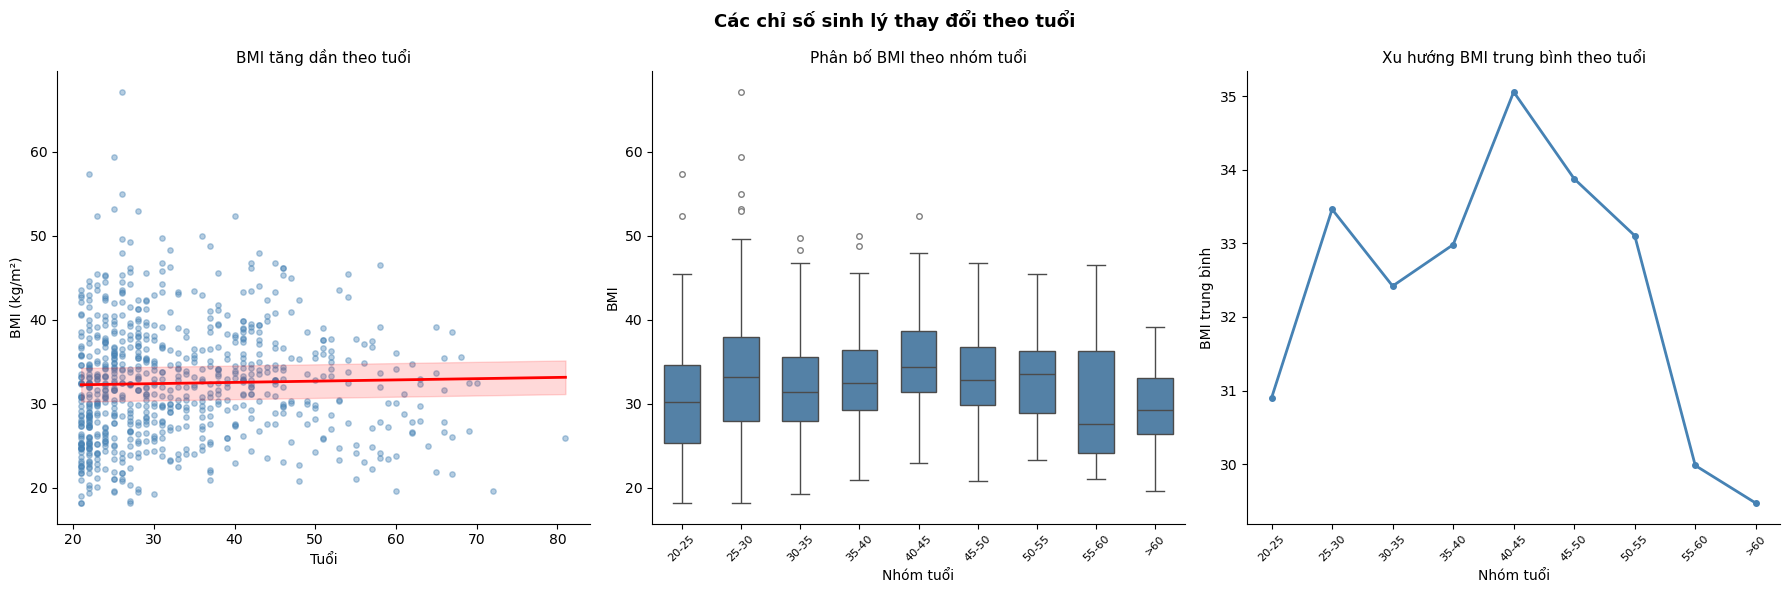

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Tạo nhóm tuổi
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, float('inf')]
labels = ['20-25','25-30','30-35','35-40','40-45','45-50','50-55','55-60','>60']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# -----------------------
# Biểu đồ 1: Scatter + đường hồi quy
# -----------------------
axes[0].scatter(df['Age'], df['BMI'], color='steelblue', alpha=0.4, s=15)

# Đường hồi quy
m, b = np.polyfit(df['Age'], df['BMI'], 1)
x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2)
axes[0].fill_between(x_line, (m * x_line + b) - 2, (m * x_line + b) + 2,
                     color='red', alpha=0.15)

axes[0].set_title("BMI tăng dần theo tuổi", fontsize=11)
axes[0].set_xlabel("Tuổi", fontsize=10)
axes[0].set_ylabel("BMI (kg/m²)", fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 2: Boxplot theo nhóm tuổi
# -----------------------
sns.boxplot(data=df, x='AgeGroup', y='BMI', ax=axes[1],
            color='steelblue', width=0.6, linewidth=1,
            flierprops=dict(marker='o', markerfacecolor='white',
                           markeredgecolor='gray', markersize=4))

axes[1].set_title("Phân bố BMI theo nhóm tuổi", fontsize=11)
axes[1].set_xlabel("Nhóm tuổi", fontsize=10)
axes[1].set_ylabel("BMI", fontsize=10)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 3: Line chart BMI trung bình theo nhóm tuổi
# -----------------------
bmi_mean = df.groupby('AgeGroup', observed=True)['BMI'].mean()

axes[2].plot(bmi_mean.index, bmi_mean.values,
             color='steelblue', linewidth=2, marker='o', markersize=4)

axes[2].set_title("Xu hướng BMI trung bình theo tuổi", fontsize=11)
axes[2].set_xlabel("Nhóm tuổi", fontsize=10)
axes[2].set_ylabel("BMI trung bình", fontsize=10)
axes[2].tick_params(axis='x', rotation=45, labelsize=8)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle("Các chỉ số sinh lý thay đổi theo tuổi",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Biểu đồ Glucose theo tuổi

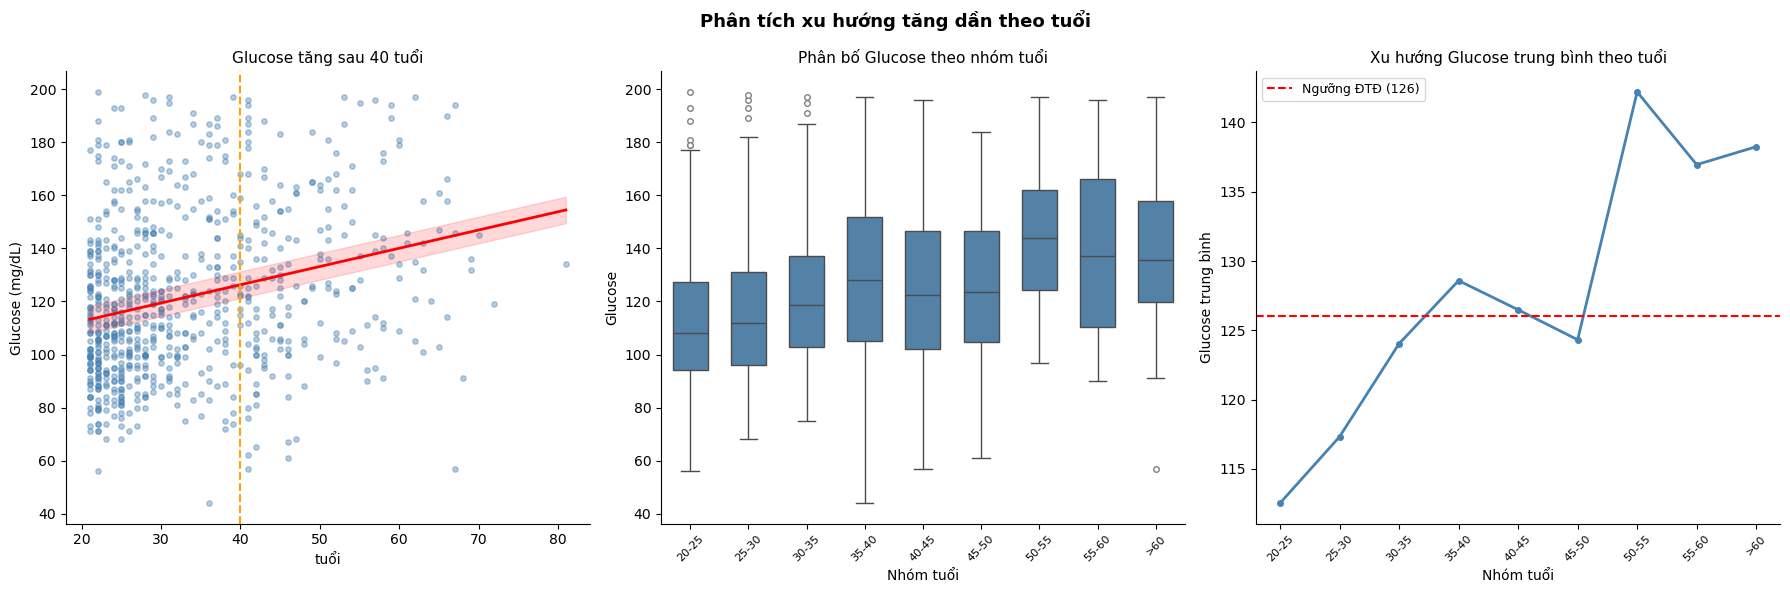

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Tạo nhóm tuổi (dùng lại từ code trước)
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, float('inf')]
labels = ['20-25','25-30','30-35','35-40','40-45','45-50','50-55','55-60','>60']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# -----------------------
# Biểu đồ 1: Scatter + đường hồi quy + đường dọc tuổi 40
# -----------------------
axes[0].scatter(df['Age'], df['Glucose'], color='steelblue', alpha=0.4, s=15)

m, b = np.polyfit(df['Age'], df['Glucose'], 1)
x_line = np.linspace(df['Age'].min(), df['Age'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2)
axes[0].fill_between(x_line, (m * x_line + b) - 5, (m * x_line + b) + 5,
                     color='red', alpha=0.15)

# Đường dọc tuổi 40
axes[0].axvline(x=40, color='orange', linestyle='--', linewidth=1.5)

axes[0].set_title("Glucose tăng sau 40 tuổi", fontsize=11)
axes[0].set_xlabel("tuổi", fontsize=10)
axes[0].set_ylabel("Glucose (mg/dL)", fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 2: Boxplot theo nhóm tuổi
# -----------------------
sns.boxplot(data=df, x='AgeGroup', y='Glucose', ax=axes[1],
            color='steelblue', width=0.6, linewidth=1,
            flierprops=dict(marker='o', markerfacecolor='white',
                           markeredgecolor='gray', markersize=4))

axes[1].set_title("Phân bố Glucose theo nhóm tuổi", fontsize=11)
axes[1].set_xlabel("Nhóm tuổi", fontsize=10)
axes[1].set_ylabel("Glucose", fontsize=10)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 3: Line chart + đường ngưỡng ĐTĐ 126
# -----------------------
glucose_mean = df.groupby('AgeGroup', observed=True)['Glucose'].mean()

axes[2].plot(glucose_mean.index, glucose_mean.values,
             color='steelblue', linewidth=2, marker='o', markersize=4)

# Đường ngưỡng ĐTĐ
axes[2].axhline(y=126, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng ĐTĐ (126)')
axes[2].legend(fontsize=9)

axes[2].set_title("Xu hướng Glucose trung bình theo tuổi", fontsize=11)
axes[2].set_xlabel("Nhóm tuổi", fontsize=10)
axes[2].set_ylabel("Glucose trung bình", fontsize=10)
axes[2].tick_params(axis='x', rotation=45, labelsize=8)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle("Phân tích xu hướng tăng dần theo tuổi",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Biểu đồ tỉ lệ mắc bệnh theo nhóm tuổi

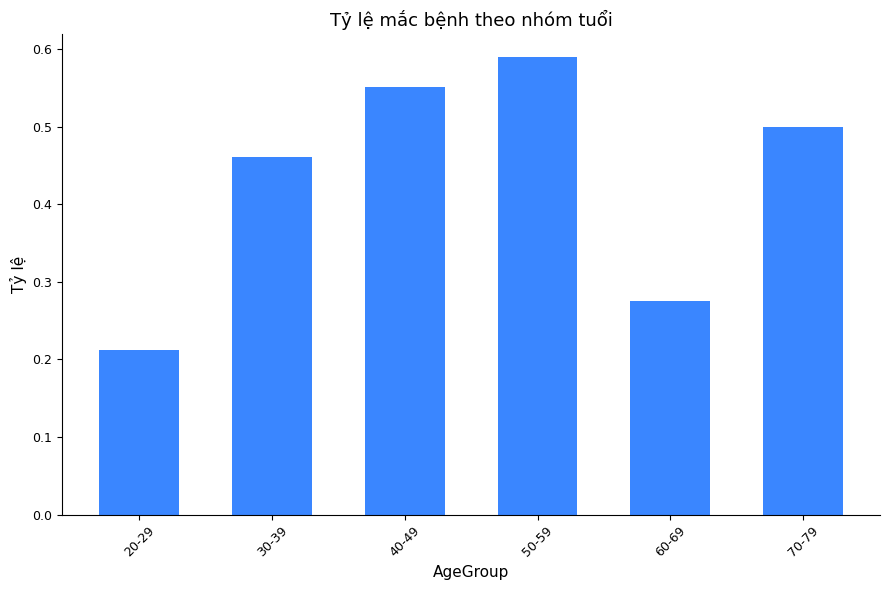

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Tạo nhóm tuổi theo thập niên
bins = [20, 30, 40, 50, 60, 70, 80]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Tính tỷ lệ mắc bệnh theo nhóm tuổi
disease_rate = df.groupby('AgeGroup', observed=True)['Outcome'].mean()

fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(disease_rate.index, disease_rate.values,
       color='#3A86FF', width=0.6, edgecolor='none')

ax.set_title("Tỷ lệ mắc bệnh theo nhóm tuổi", fontsize=13)
ax.set_xlabel("AgeGroup", fontsize=11)
ax.set_ylabel("Tỷ lệ", fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Tỉ lệ mắc bệnh theo BMI

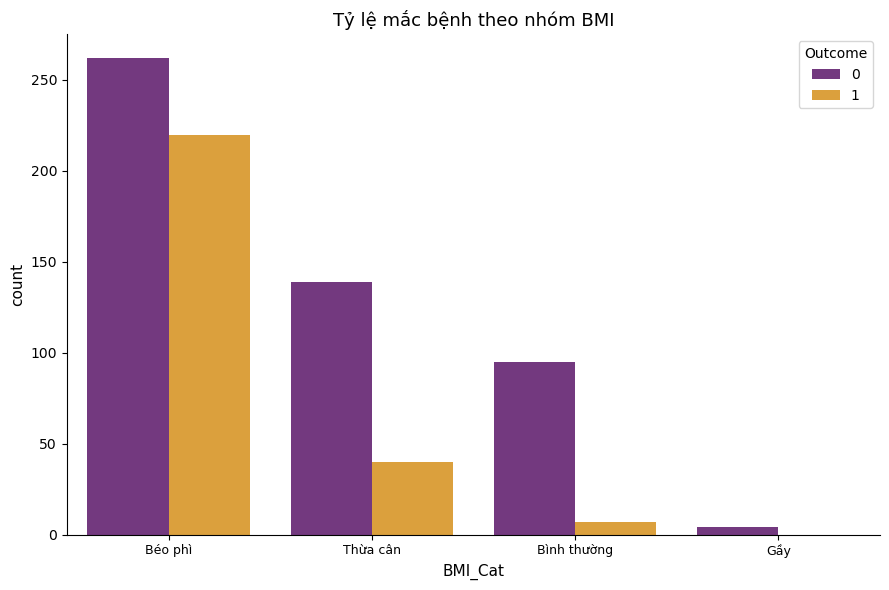

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Phân loại BMI
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Gầy'
    elif bmi < 25:
        return 'Bình thường'
    elif bmi < 30:
        return 'Thừa cân'
    else:
        return 'Béo phì'

df['BMI_Cat'] = df['BMI'].apply(bmi_category)

order = ['Béo phì', 'Thừa cân', 'Bình thường', 'Gầy']

fig, ax = plt.subplots(figsize=(9, 6))

sns.countplot(data=df, x='BMI_Cat', hue='Outcome',
              order=order,
              palette={0: '#7B2D8B', 1: '#F5A623'},  # tím + vàng cam
              ax=ax)

ax.set_title("Tỷ lệ mắc bệnh theo nhóm BMI", fontsize=13)
ax.set_xlabel("BMI_Cat", fontsize=11)
ax.set_ylabel("count", fontsize=11)
ax.tick_params(axis='x', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Bảng tỷ lệ mắc bệnh theo BMI

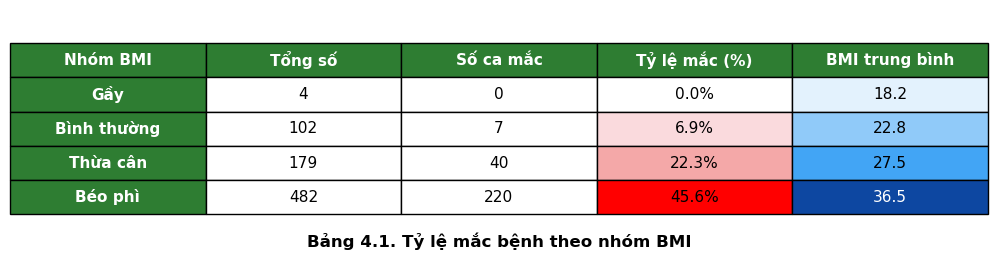

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Tính toán từ dữ liệu
order = ['Gầy', 'Bình thường', 'Thừa cân', 'Béo phì']

summary = df.groupby('BMI_Cat').agg(
    Tổng_số=('Outcome', 'count'),
    Số_ca_mắc=('Outcome', 'sum'),
    BMI_trung_bình=('BMI', 'mean')
).reindex(order)

summary['Tỷ_lệ_mắc'] = (summary['Số_ca_mắc'] / summary['Tổng_số'] * 100).round(1).astype(str) + '%'
summary['BMI_trung_bình'] = summary['BMI_trung_bình'].round(1)

# Dữ liệu bảng
table_data = []
for idx, row in summary.iterrows():
    table_data.append([idx, int(row['Tổng_số']), int(row['Số_ca_mắc']),
                       row['Tỷ_lệ_mắc'], row['BMI_trung_bình']])

columns = ['Nhóm BMI', 'Tổng số', 'Số ca mắc', 'Tỷ lệ mắc (%)', 'BMI trung bình']

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

table = ax.table(cellText=table_data, colLabels=columns,
                 loc='center', cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

# Màu header
for j in range(len(columns)):
    table[0, j].set_facecolor('#2E7D32')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Màu cột Nhóm BMI
for i in range(1, len(order) + 1):
    table[i, 0].set_facecolor('#2E7D32')
    table[i, 0].set_text_props(color='white', fontweight='bold')

# Màu cột Tỷ lệ mắc theo mức độ
ty_le_colors = ['#FFFFFF', '#FADADD', '#F4A8A8', '#FF0000']
for i, color in enumerate(ty_le_colors):
    table[i+1, 3].set_facecolor(color)

# Màu cột BMI trung bình theo mức độ
bmi_colors = ['#E3F2FD', '#90CAF9', '#42A5F5', '#0D47A1']
for i, color in enumerate(bmi_colors):
    table[i+1, 4].set_facecolor(color)
    if i == 3:
        table[i+1, 4].set_text_props(color='white')

plt.suptitle("Bảng 4.1. Tỷ lệ mắc bệnh theo nhóm BMI",
             fontsize=12, fontweight='bold', y=0.1)
plt.tight_layout()
plt.show()

### Biểu đồ BMI kết hợp với các yếu tố khác

#### BIM + Glucose

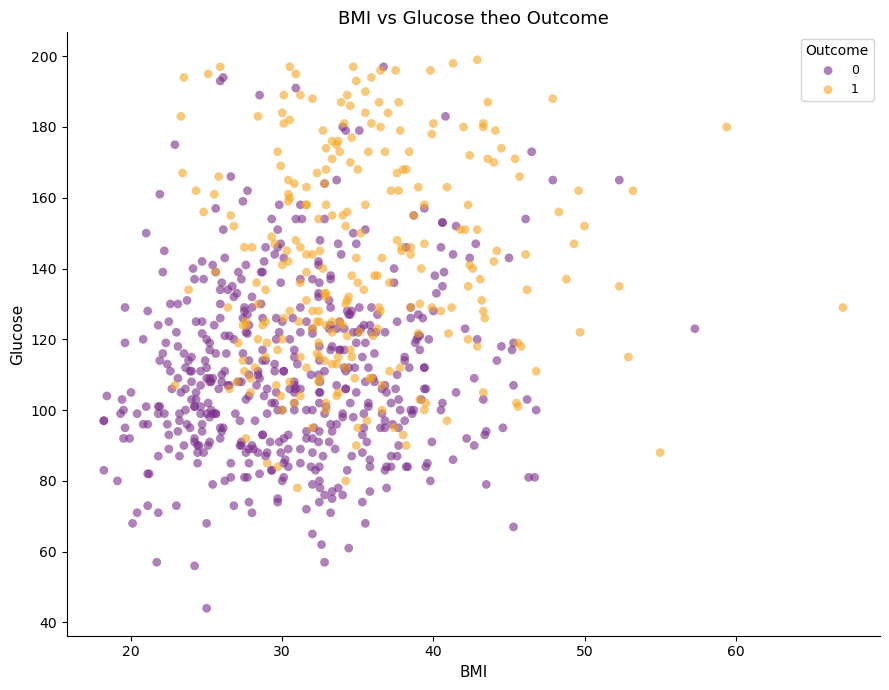

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

colors = {0: '#7B2D8B', 1: '#F5A623'}
labels = {0: '0', 1: '1'}

for outcome, group in df.groupby('Outcome'):
    ax.scatter(group['BMI'], group['Glucose'],
               color=colors[outcome],
               label=labels[outcome],
               alpha=0.6, s=40, edgecolors='none')

ax.set_title("BMI vs Glucose theo Outcome", fontsize=13)
ax.set_xlabel("BMI", fontsize=11)
ax.set_ylabel("Glucose", fontsize=11)
ax.legend(title='Outcome', fontsize=9, title_fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

##### BMI+AGE

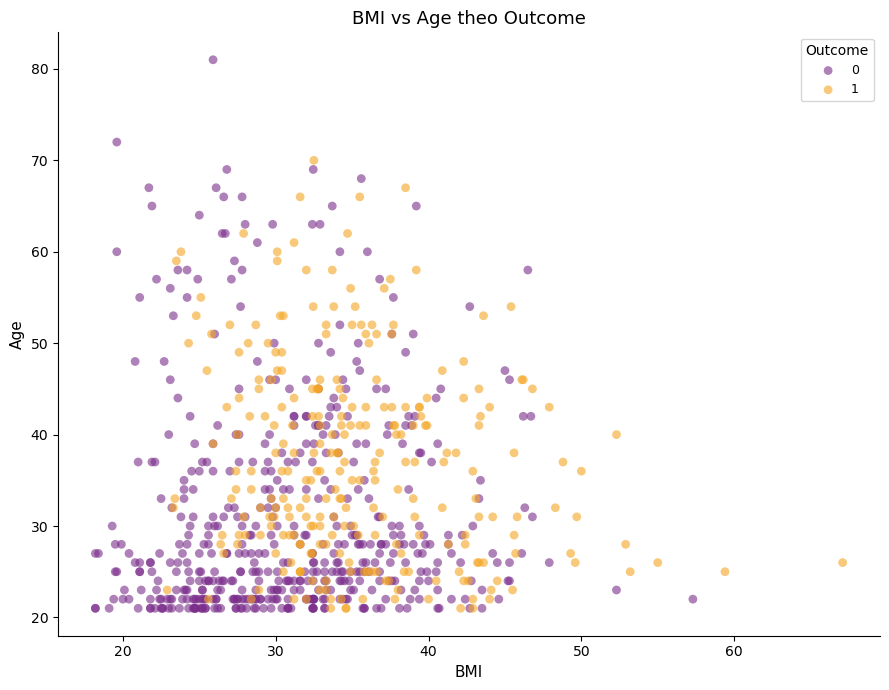

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

colors = {0: '#7B2D8B', 1: '#F5A623'}

for outcome, group in df.groupby('Outcome'):
    ax.scatter(group['BMI'], group['Age'],
               color=colors[outcome],
               label=str(outcome),
               alpha=0.6, s=40, edgecolors='none')

ax.set_title("BMI vs Age theo Outcome", fontsize=13)
ax.set_xlabel("BMI", fontsize=11)
ax.set_ylabel("Age", fontsize=11)
ax.legend(title='Outcome', fontsize=9, title_fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### BMI+Isulin

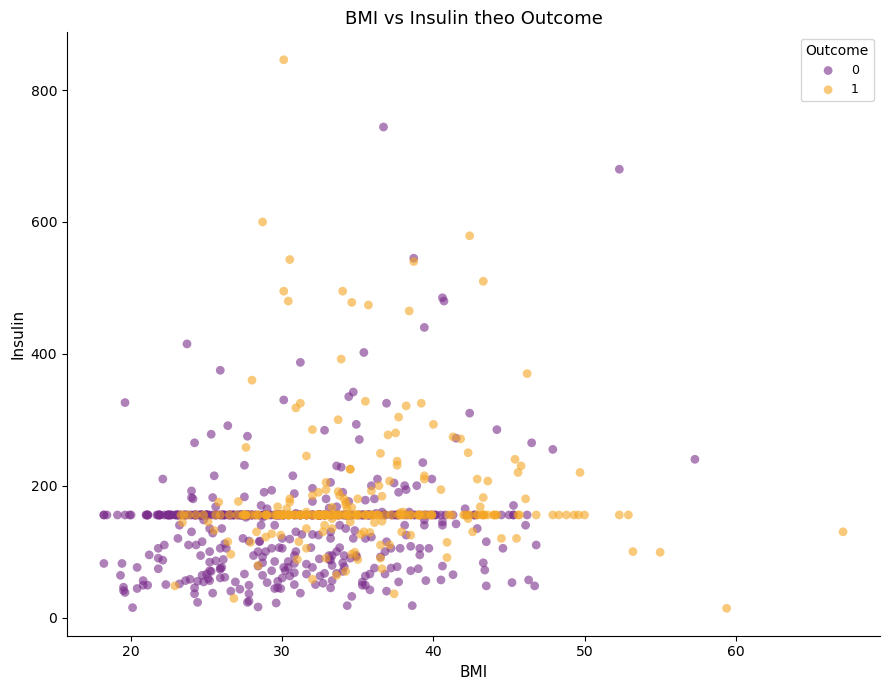

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

colors = {0: '#7B2D8B', 1: '#F5A623'}

for outcome, group in df.groupby('Outcome'):
    ax.scatter(group['BMI'], group['Insulin'],
               color=colors[outcome],
               label=str(outcome),
               alpha=0.6, s=40, edgecolors='none')

ax.set_title("BMI vs Insulin theo Outcome", fontsize=13)
ax.set_xlabel("BMI", fontsize=11)
ax.set_ylabel("Insulin", fontsize=11)
ax.legend(title='Outcome', fontsize=9, title_fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### BMI+BloodPressure

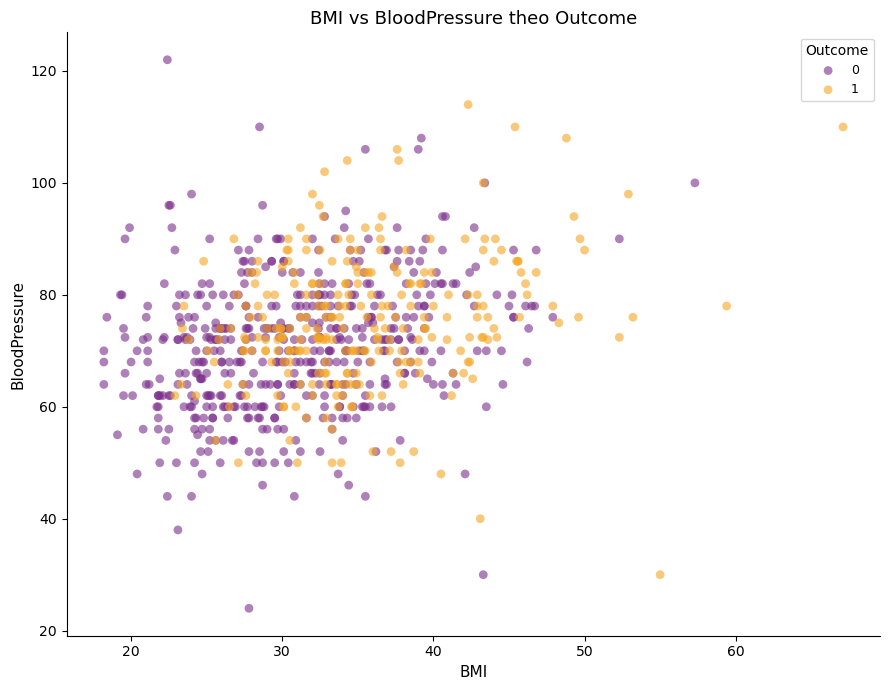

In [15]:
import matplotlib.pyplot as plt

colors = {0: '#7B2D8B', 1: '#F5A623'}

fig, ax = plt.subplots(figsize=(9, 7))

for outcome, group in df.groupby('Outcome'):
    ax.scatter(group['BMI'], group['BloodPressure'],
               color=colors[outcome],
               label=str(outcome),
               alpha=0.6, s=40, edgecolors='none')

ax.set_title("BMI vs BloodPressure theo Outcome", fontsize=13)
ax.set_xlabel("BMI", fontsize=11)
ax.set_ylabel("BloodPressure", fontsize=11)
ax.legend(title='Outcome', fontsize=9, title_fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### BMI+SkinThickness

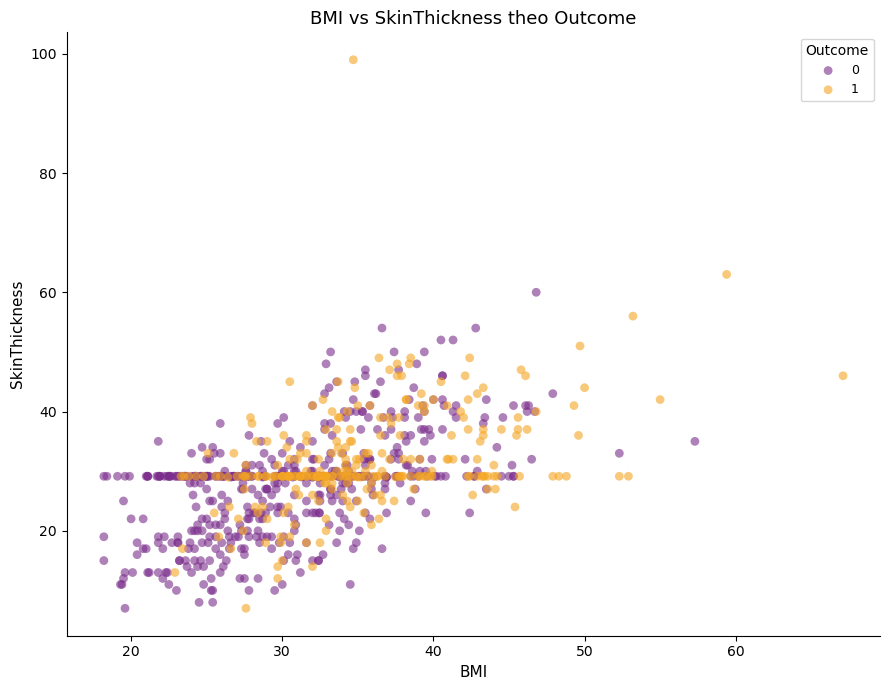

In [16]:
fig, ax = plt.subplots(figsize=(9, 7))

for outcome, group in df.groupby('Outcome'):
    ax.scatter(group['BMI'], group['SkinThickness'],
               color=colors[outcome],
               label=str(outcome),
               alpha=0.6, s=40, edgecolors='none')

ax.set_title("BMI vs SkinThickness theo Outcome", fontsize=13)
ax.set_xlabel("BMI", fontsize=11)
ax.set_ylabel("SkinThickness", fontsize=11)
ax.legend(title='Outcome', fontsize=9, title_fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Biểu đồ phân bố bệnh theo nồng độ Glucose

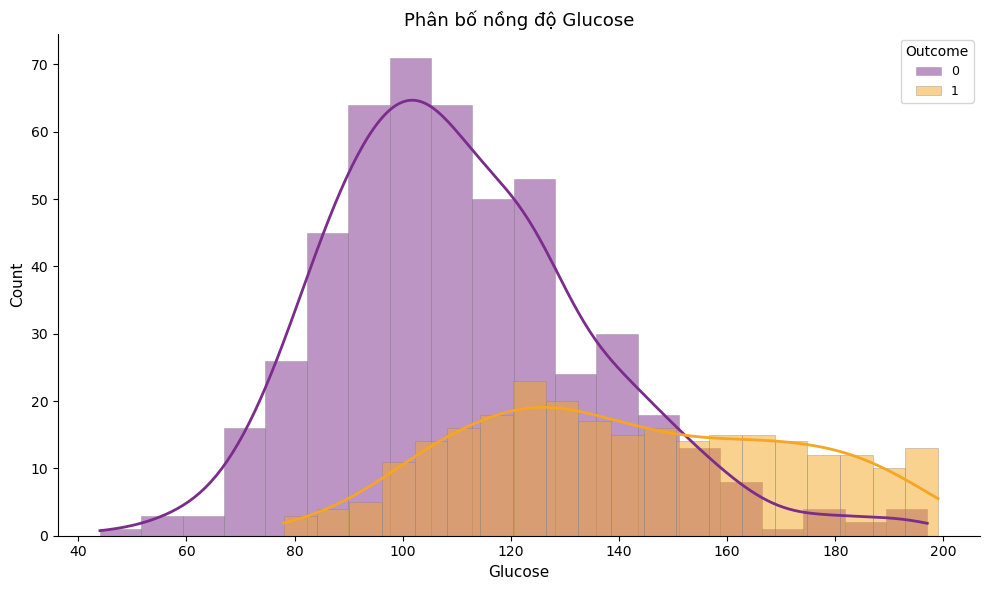

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(10, 6))

colors = {0: '#7B2D8B', 1: '#F5A623'}

for outcome, group in df.groupby('Outcome'):
    # Vẽ histogram
    counts, bins, _ = ax.hist(group['Glucose'], bins=20, alpha=0.5,
                               color=colors[outcome], edgecolor='gray',
                               linewidth=0.5, label=str(outcome))

    # Vẽ KDE scale theo count
    kde = gaussian_kde(group['Glucose'])
    x = np.linspace(group['Glucose'].min(), group['Glucose'].max(), 300)
    bin_width = bins[1] - bins[0]
    ax.plot(x, kde(x) * len(group['Glucose']) * bin_width,
            color=colors[outcome], linewidth=2)

ax.set_title("Phân bố nồng độ Glucose", fontsize=13)
ax.set_xlabel("Glucose", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.legend(title='Outcome', fontsize=9, title_fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Glucose+Isulin

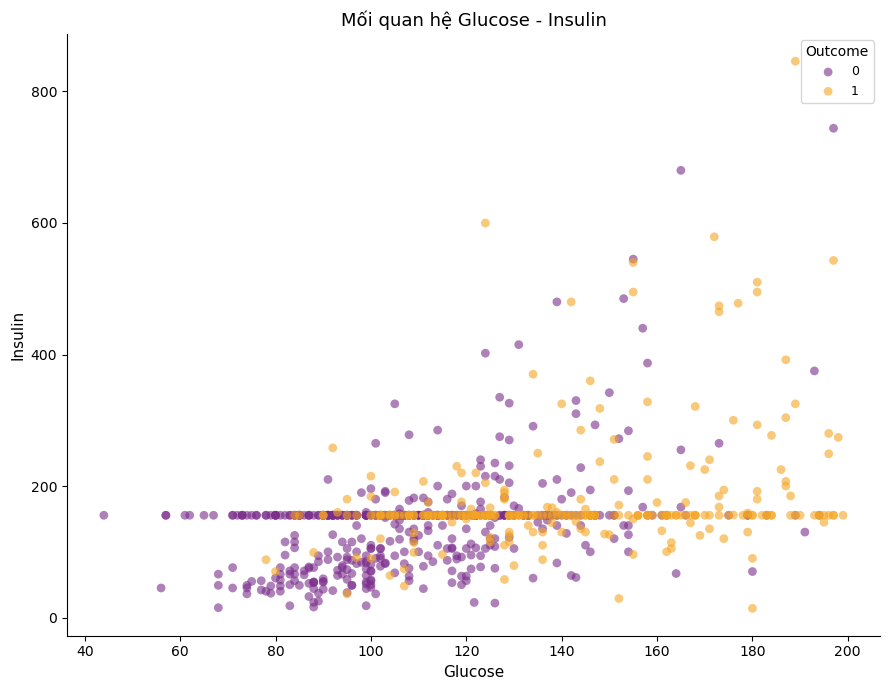

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

colors = {0: '#7B2D8B', 1: '#F5A623'}

for outcome, group in df.groupby('Outcome'):
    ax.scatter(group['Glucose'], group['Insulin'],
               color=colors[outcome],
               label=str(outcome),
               alpha=0.6, s=40, edgecolors='none')

ax.set_title("Mối quan hệ Glucose - Insulin", fontsize=13)
ax.set_xlabel("Glucose", fontsize=11)
ax.set_ylabel("Insulin", fontsize=11)
ax.legend(title='Outcome', fontsize=9, title_fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Biểu đồ phân bố theo di truyền

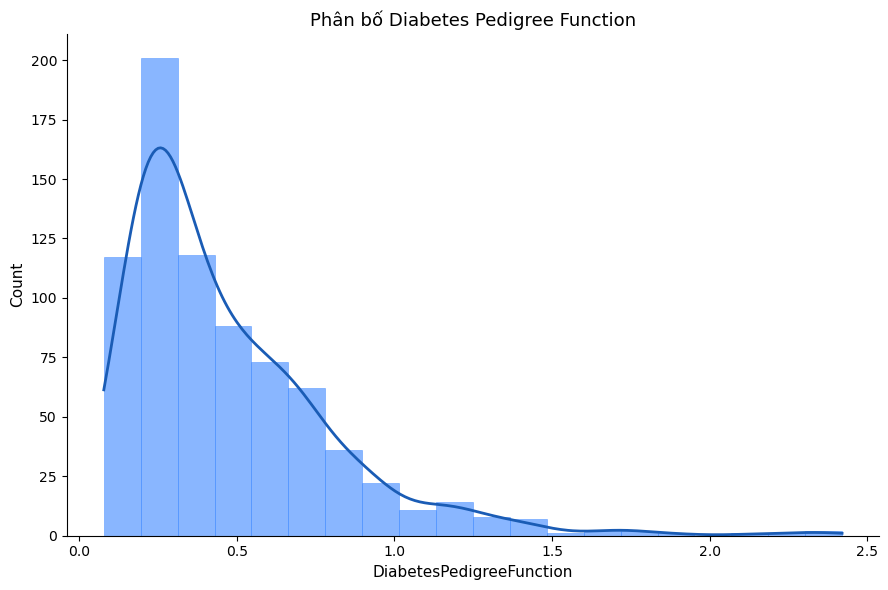

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 6))

col = 'DiabetesPedigreeFunction'

# Vẽ histogram
counts, bins, _ = ax.hist(df[col], bins=20, alpha=0.6,
                           color='#3A86FF', edgecolor='#3A86FF',
                           linewidth=0.5)

# Vẽ KDE scale theo count
kde = gaussian_kde(df[col])
x = np.linspace(df[col].min(), df[col].max(), 300)
bin_width = bins[1] - bins[0]
ax.plot(x, kde(x) * len(df[col]) * bin_width,
        color='#1a5cb5', linewidth=2)

ax.set_title("Phân bố Diabetes Pedigree Function", fontsize=13)
ax.set_xlabel("DiabetesPedigreeFunction", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Tác động của yếu tố di truyền

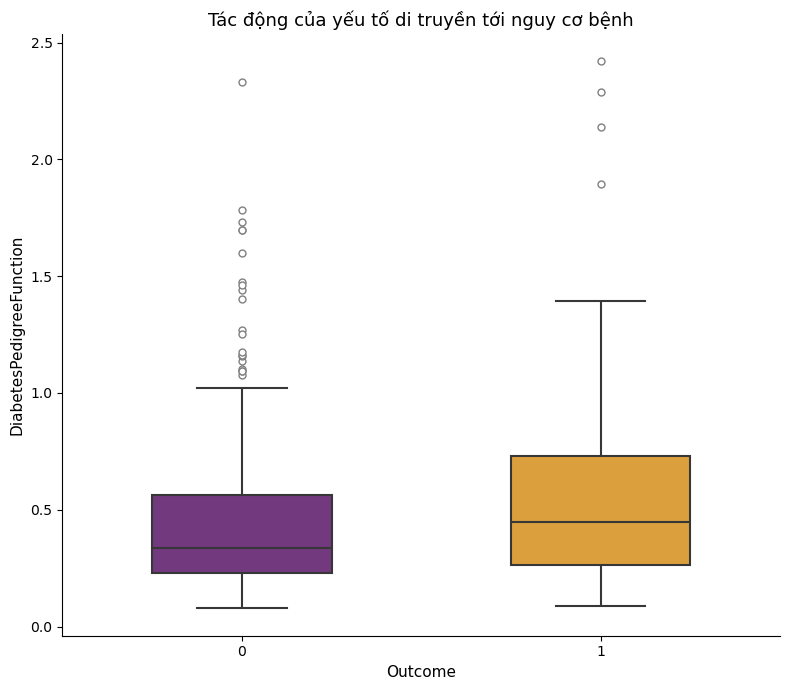

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 7))

sns.boxplot(data=df, x='Outcome', y='DiabetesPedigreeFunction',
            hue='Outcome', legend=False,
            palette={0: '#7B2D8B', 1: '#F5A623'},  # ← dùng integer không dùng string
            width=0.5, linewidth=1.5,
            flierprops=dict(marker='o', markerfacecolor='white',
                           markeredgecolor='gray', markersize=5),
            ax=ax)

ax.set_title("Tác động của yếu tố di truyền tới nguy cơ bệnh", fontsize=13)
ax.set_xlabel("Outcome", fontsize=11)
ax.set_ylabel("DiabetesPedigreeFunction", fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Di truyền +Gluocose

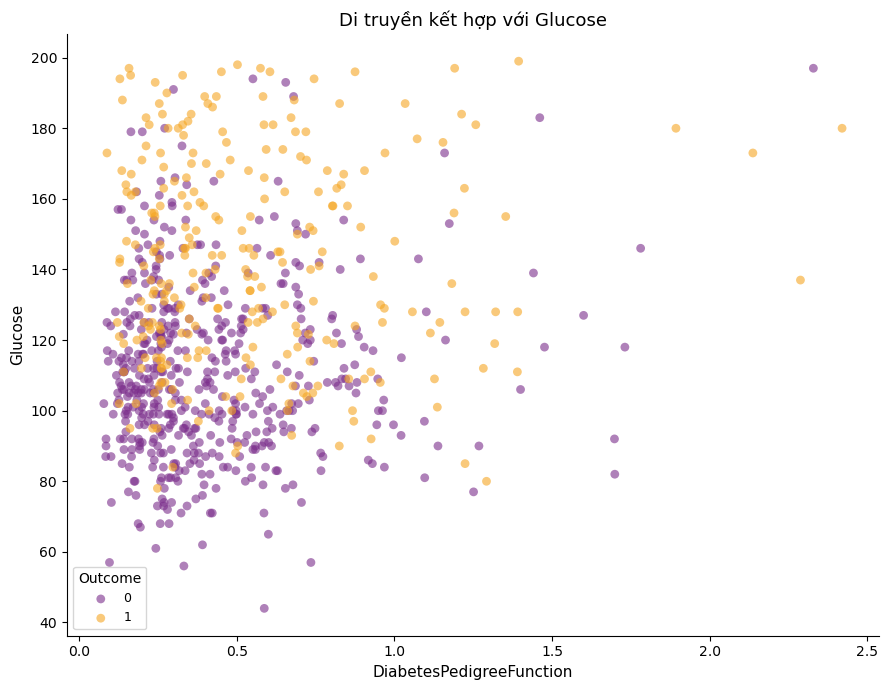

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

colors = {0: '#7B2D8B', 1: '#F5A623'}

for outcome, group in df.groupby('Outcome'):
    ax.scatter(group['DiabetesPedigreeFunction'], group['Glucose'],
               color=colors[outcome],
               label=str(outcome),
               alpha=0.6, s=40, edgecolors='none')

ax.set_title("Di truyền kết hợp với Glucose", fontsize=13)
ax.set_xlabel("DiabetesPedigreeFunction", fontsize=11)
ax.set_ylabel("Glucose", fontsize=11)
ax.legend(title='Outcome', fontsize=9, title_fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Phân tích theo số lần mang thai

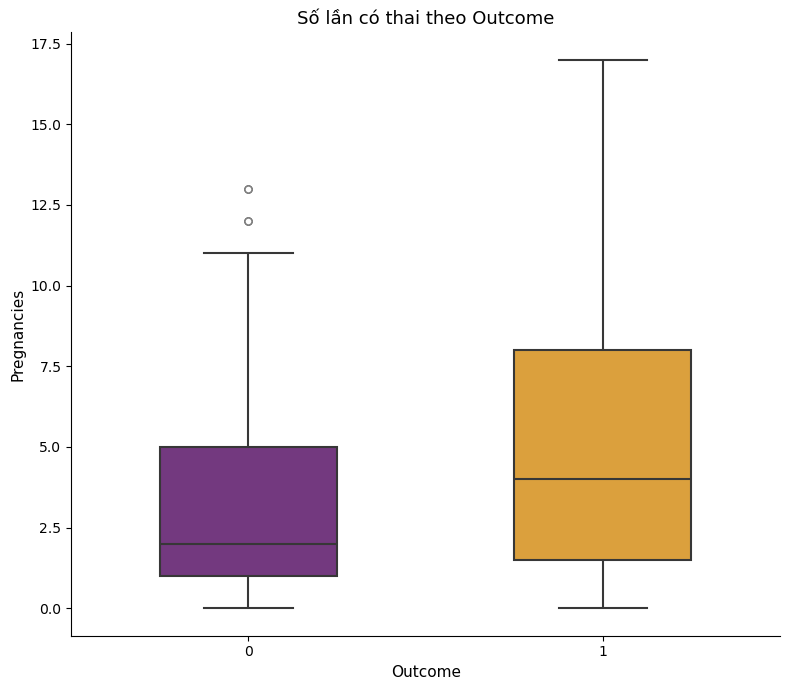

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 7))

sns.boxplot(data=df, x='Outcome', y='Pregnancies',
            hue='Outcome', legend=False,
            palette={0: '#7B2D8B', 1: '#F5A623'},
            width=0.5, linewidth=1.5,
            flierprops=dict(marker='o', markerfacecolor='white',
                           markeredgecolor='gray', markersize=5),
            ax=ax)

ax.set_title("Số lần có thai theo Outcome", fontsize=13)
ax.set_xlabel("Outcome", fontsize=11)
ax.set_ylabel("Pregnancies", fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Nguy cơ mắc bệnh theo số lần có thai

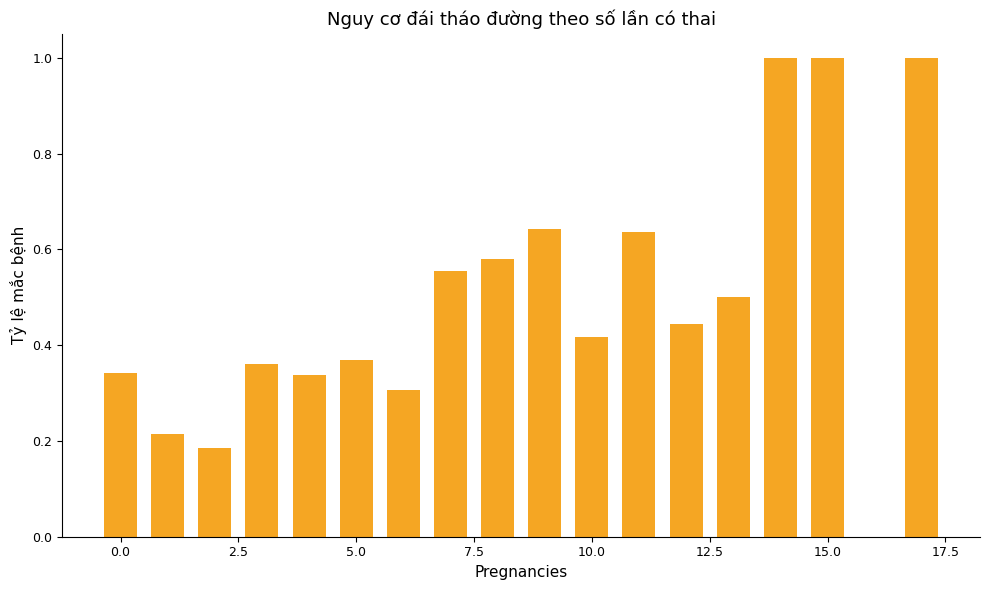

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

pregnancy_rate = df.groupby('Pregnancies')['Outcome'].mean()

ax.bar(pregnancy_rate.index, pregnancy_rate.values,
       color='#F5A623', width=0.7, edgecolor='none')

ax.set_title("Nguy cơ đái tháo đường theo số lần có thai", fontsize=13)
ax.set_xlabel("Pregnancies", fontsize=11)
ax.set_ylabel("Tỷ lệ mắc bệnh", fontsize=11)
ax.tick_params(axis='both', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Ma Trận tươgn quan

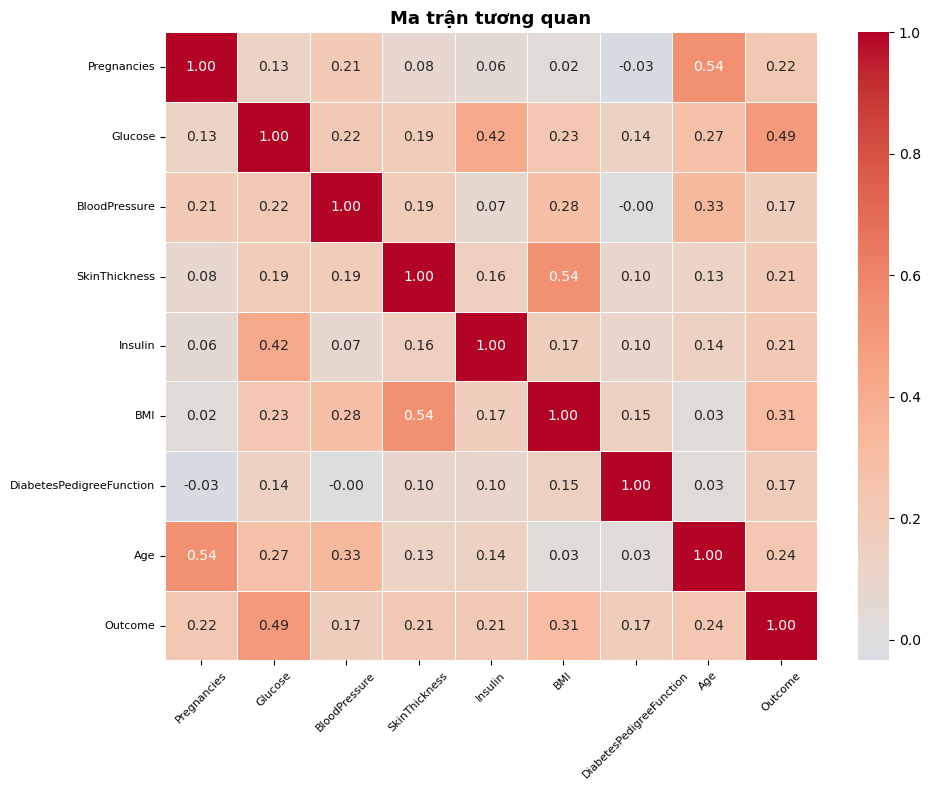

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 8))

# Tính ma trận tương quan
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            ax=ax)

ax.set_title("Ma trận tương quan", fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

### Phân tích các cặp biến quan trọng

#### Glucose theo outcome

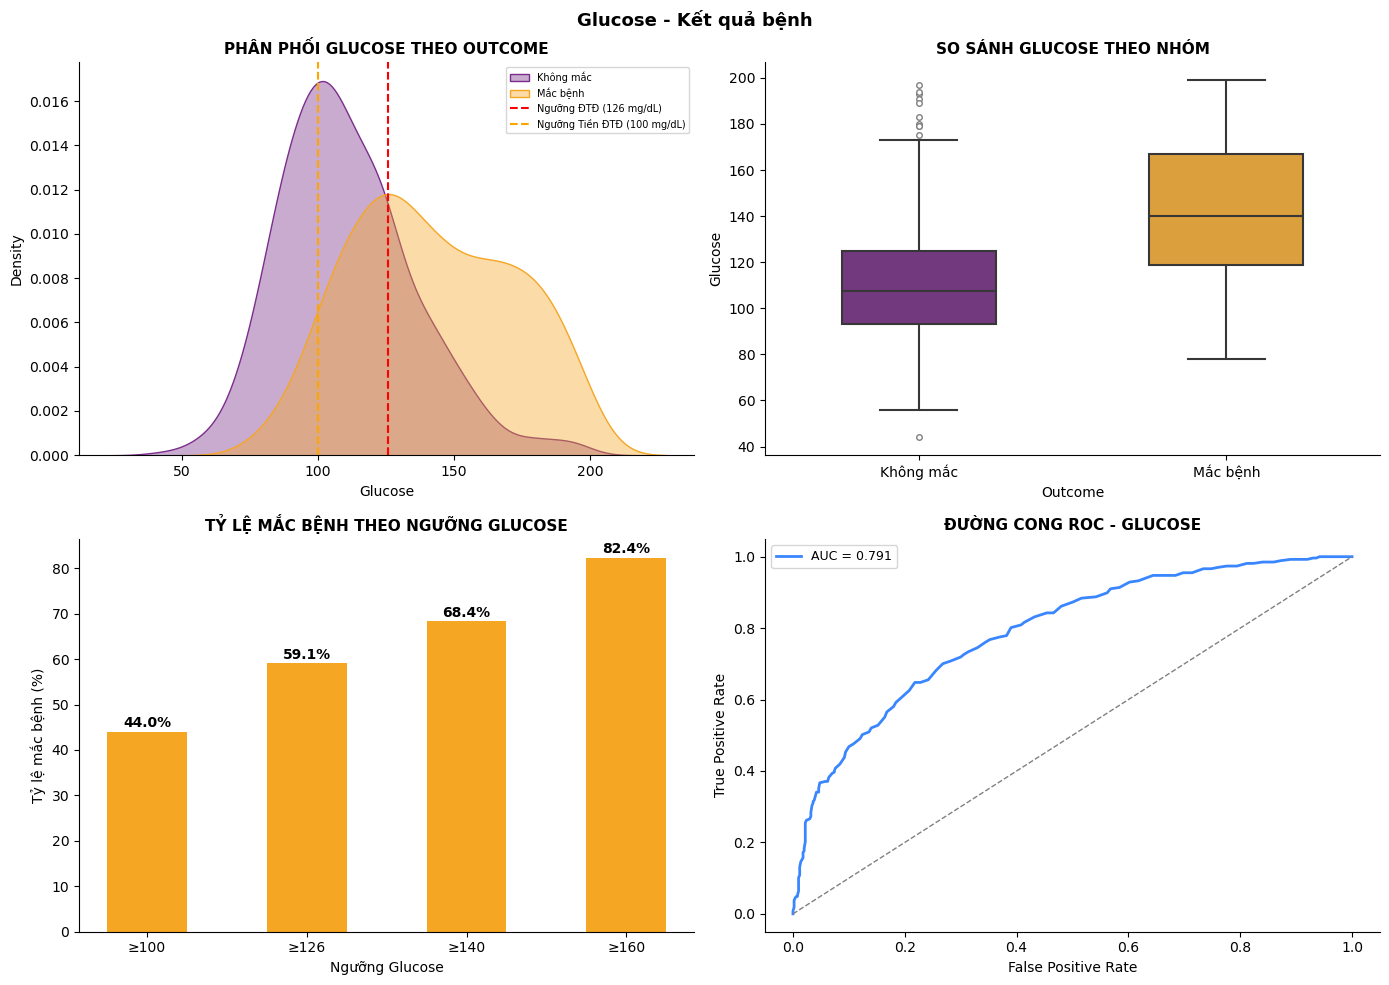

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -----------------------
# Biểu đồ 1: KDE phân phối Glucose theo Outcome
# -----------------------
for outcome, group in df.groupby('Outcome'):
    sns.kdeplot(group['Glucose'], ax=axes[0, 0],
                fill=True, alpha=0.4,
                color='#7B2D8B' if outcome == 0 else '#F5A623',
                label='Không mắc' if outcome == 0 else 'Mắc bệnh')

axes[0, 0].axvline(126, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng ĐTĐ (126 mg/dL)')
axes[0, 0].axvline(100, color='orange', linestyle='--', linewidth=1.5, label='Ngưỡng Tiền ĐTĐ (100 mg/dL)')
axes[0, 0].set_title("PHÂN PHỐI GLUCOSE THEO OUTCOME", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Glucose", fontsize=10)
axes[0, 0].set_ylabel("Density", fontsize=10)
axes[0, 0].legend(fontsize=7)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 2: Boxplot Glucose theo Outcome
# -----------------------
df_plot = df.copy()
df_plot['Outcome_label'] = df_plot['Outcome'].map({0: 'Không mắc', 1: 'Mắc bệnh'})

sns.boxplot(data=df_plot, x='Outcome_label', y='Glucose',
            hue='Outcome_label', legend=False,
            palette={'Không mắc': '#7B2D8B', 'Mắc bệnh': '#F5A623'},
            width=0.5, linewidth=1.5,
            flierprops=dict(marker='o', markerfacecolor='white',
                           markeredgecolor='gray', markersize=4),
            ax=axes[0, 1])

axes[0, 1].set_title("SO SÁNH GLUCOSE THEO NHÓM", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Outcome", fontsize=10)
axes[0, 1].set_ylabel("Glucose", fontsize=10)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 3: Tỷ lệ mắc bệnh theo ngưỡng Glucose
# -----------------------
thresholds = [100, 126, 140, 160]
labels_thresh = ['≥100', '≥126', '≥140', '≥160']
rates = [df[df['Glucose'] >= t]['Outcome'].mean() * 100 for t in thresholds]

bars = axes[1, 0].bar(labels_thresh, rates, color='#F5A623', width=0.5, edgecolor='none')

for bar, rate in zip(bars, rates):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1,
                    f'{rate:.1f}%', ha='center', fontsize=10, fontweight='bold')

axes[1, 0].set_title("TỶ LỆ MẮC BỆNH THEO NGƯỠNG GLUCOSE", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Ngưỡng Glucose", fontsize=10)
axes[1, 0].set_ylabel("Tỷ lệ mắc bệnh (%)", fontsize=10)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 4: Đường cong ROC
# -----------------------
fpr, tpr, _ = roc_curve(df['Outcome'], df['Glucose'])
roc_auc = auc(fpr, tpr)

axes[1, 1].plot(fpr, tpr, color='#3A86FF', linewidth=2, label=f'AUC = {roc_auc:.3f}')
axes[1, 1].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
axes[1, 1].set_title("ĐƯỜNG CONG ROC - GLUCOSE", fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel("False Positive Rate", fontsize=10)
axes[1, 1].set_ylabel("True Positive Rate", fontsize=10)
axes[1, 1].legend(fontsize=9)
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

plt.suptitle("Glucose - Kết quả bệnh", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### BMI+Độ dày da

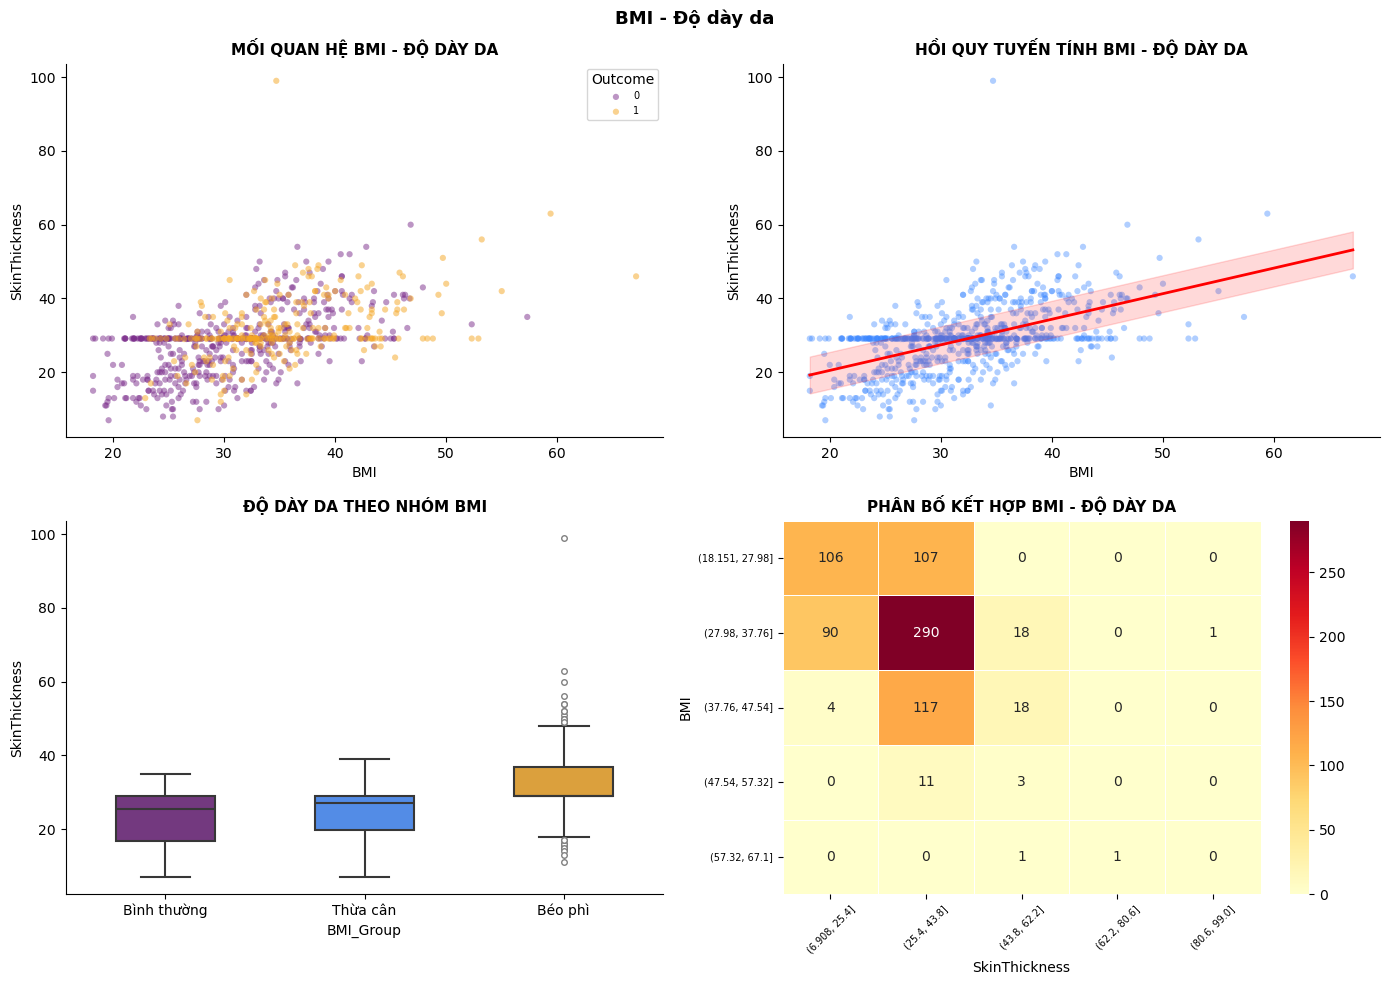

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -----------------------
# Biểu đồ 1: Scatter BMI vs SkinThickness theo Outcome
# -----------------------
colors = {0: '#7B2D8B', 1: '#F5A623'}
for outcome, group in df.groupby('Outcome'):
    axes[0, 0].scatter(group['BMI'], group['SkinThickness'],
                       color=colors[outcome], label=str(outcome),
                       alpha=0.5, s=20, edgecolors='none')

axes[0, 0].set_title("MỐI QUAN HỆ BMI - ĐỘ DÀY DA", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("BMI", fontsize=10)
axes[0, 0].set_ylabel("SkinThickness", fontsize=10)
axes[0, 0].legend(title='Outcome', fontsize=7)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 2: Scatter + đường hồi quy
# -----------------------
axes[0, 1].scatter(df['BMI'], df['SkinThickness'],
                   color='#3A86FF', alpha=0.4, s=20, edgecolors='none')

m, b = np.polyfit(df['BMI'], df['SkinThickness'], 1)
x_line = np.linspace(df['BMI'].min(), df['BMI'].max(), 300)
axes[0, 1].plot(x_line, m * x_line + b, color='red', linewidth=2)
axes[0, 1].fill_between(x_line,
                         (m * x_line + b) - 5,
                         (m * x_line + b) + 5,
                         color='red', alpha=0.15)

axes[0, 1].set_title("HỒI QUY TUYẾN TÍNH BMI - ĐỘ DÀY DA", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("BMI", fontsize=10)
axes[0, 1].set_ylabel("SkinThickness", fontsize=10)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 3: Boxplot SkinThickness theo nhóm BMI
# -----------------------
df['BMI_Group'] = pd.cut(df['BMI'],
                          bins=[0, 25, 30, 100],
                          labels=['Bình thường', 'Thừa cân', 'Béo phì'])

sns.boxplot(data=df, x='BMI_Group', y='SkinThickness',
            hue='BMI_Group', legend=False,
            palette={'Bình thường': '#7B2D8B',
                     'Thừa cân': '#3A86FF',
                     'Béo phì': '#F5A623'},
            width=0.5, linewidth=1.5,
            flierprops=dict(marker='o', markerfacecolor='white',
                           markeredgecolor='gray', markersize=4),
            ax=axes[1, 0])

axes[1, 0].set_title("ĐỘ DÀY DA THEO NHÓM BMI", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("BMI_Group", fontsize=10)
axes[1, 0].set_ylabel("SkinThickness", fontsize=10)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 4: Heatmap phân bố kết hợp BMI - SkinThickness
# -----------------------
df['BMI_bin'] = pd.cut(df['BMI'], bins=5)
df['Skin_bin'] = pd.cut(df['SkinThickness'], bins=5)

pivot = df.groupby(['BMI_bin', 'Skin_bin'], observed=True).size().unstack(fill_value=0)

sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1, 1])

axes[1, 1].set_title("PHÂN BỐ KẾT HỢP BMI - ĐỘ DÀY DA", fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel("SkinThickness", fontsize=10)
axes[1, 1].set_ylabel("BMI", fontsize=10)
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1, 1].tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle("BMI - Độ dày da", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Tuổi +Số lần mang thai

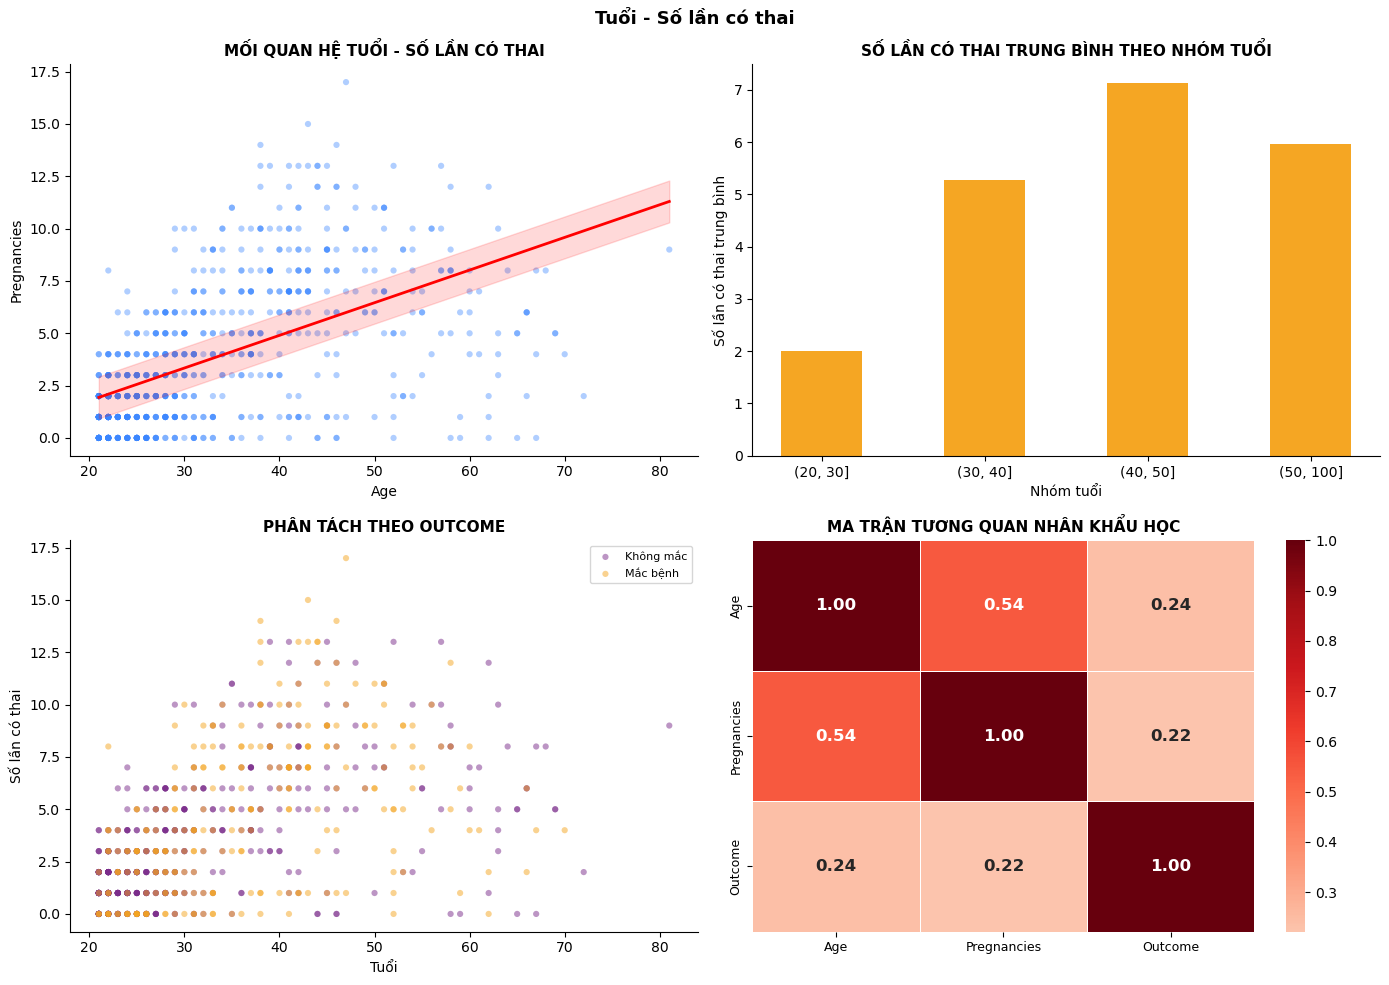

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -----------------------
# Biểu đồ 1: Scatter + đường hồi quy Age vs Pregnancies
# -----------------------
axes[0, 0].scatter(df['Age'], df['Pregnancies'],
                   color='#3A86FF', alpha=0.4, s=20, edgecolors='none')

m, b = np.polyfit(df['Age'], df['Pregnancies'], 1)
x_line = np.linspace(df['Age'].min(), df['Age'].max(), 300)
axes[0, 0].plot(x_line, m * x_line + b, color='red', linewidth=2)
axes[0, 0].fill_between(x_line, (m * x_line + b) - 1, (m * x_line + b) + 1,
                        color='red', alpha=0.15)

axes[0, 0].set_title("MỐI QUAN HỆ TUỔI - SỐ LẦN CÓ THAI", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Age", fontsize=10)
axes[0, 0].set_ylabel("Pregnancies", fontsize=10)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 2: Bar chart số lần có thai TB theo nhóm tuổi
# -----------------------
age_bins = [20, 30, 40, 50, 100]
age_labels = ['(20, 30]', '(30, 40]', '(40, 50]', '(50, 100]']
df['AgeGroup2'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

preg_mean = df.groupby('AgeGroup2', observed=True)['Pregnancies'].mean()

axes[0, 1].bar(preg_mean.index, preg_mean.values,
               color='#F5A623', width=0.5, edgecolor='none')

axes[0, 1].set_title("SỐ LẦN CÓ THAI TRUNG BÌNH THEO NHÓM TUỔI", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Nhóm tuổi", fontsize=10)
axes[0, 1].set_ylabel("Số lần có thai trung bình", fontsize=10)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 3: Scatter phân tách theo Outcome
# -----------------------
colors = {0: '#7B2D8B', 1: '#F5A623'}
labels = {0: 'Không mắc', 1: 'Mắc bệnh'}

for outcome, group in df.groupby('Outcome'):
    axes[1, 0].scatter(group['Age'], group['Pregnancies'],
                       color=colors[outcome], label=labels[outcome],
                       alpha=0.5, s=20, edgecolors='none')

axes[1, 0].set_title("PHÂN TÁCH THEO OUTCOME", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Tuổi", fontsize=10)
axes[1, 0].set_ylabel("Số lần có thai", fontsize=10)
axes[1, 0].legend(fontsize=8)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 4: Heatmap tương quan Age, Pregnancies, Outcome
# -----------------------
corr_cols = df[['Age', 'Pregnancies', 'Outcome']].corr()

sns.heatmap(corr_cols, annot=True, fmt='.2f',
            cmap='Reds', center=0.5,
            linewidths=0.5, ax=axes[1, 1],
            annot_kws={'size': 12, 'fontweight': 'bold'})

axes[1, 1].set_title("MA TRẬN TƯƠNG QUAN NHÂN KHẨU HỌC", fontsize=11, fontweight='bold')
axes[1, 1].tick_params(axis='both', labelsize=9)

plt.suptitle("Tuổi - Số lần có thai", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Glucose+Isulin

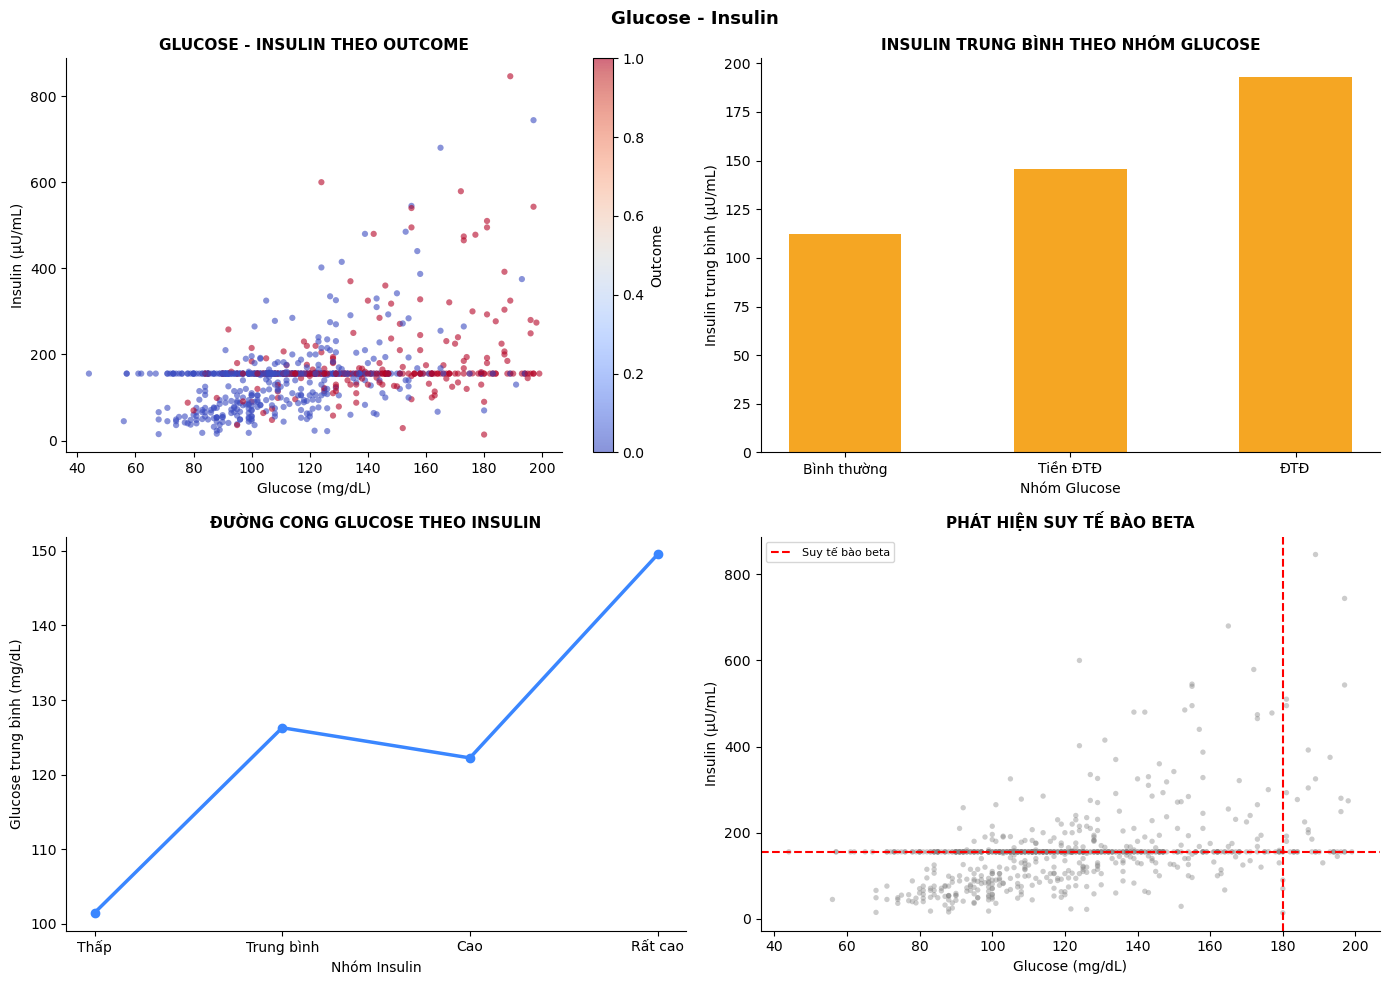

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -----------------------
# Biểu đồ 1: Scatter Glucose vs Insulin theo Outcome (colorbar)
# -----------------------
sc = axes[0, 0].scatter(df['Glucose'], df['Insulin'],
                        c=df['Outcome'], cmap='coolwarm',
                        alpha=0.6, s=20, edgecolors='none')
plt.colorbar(sc, ax=axes[0, 0], label='Outcome')
axes[0, 0].set_title("GLUCOSE - INSULIN THEO OUTCOME", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Glucose (mg/dL)", fontsize=10)
axes[0, 0].set_ylabel("Insulin (μU/mL)", fontsize=10)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 2: Bar chart Insulin TB theo nhóm Glucose
# -----------------------
def glucose_group(g):
    if g < 100: return 'Bình thường'
    elif g < 126: return 'Tiền ĐTĐ'
    else: return 'ĐTĐ'

df['GlucoseGroup'] = df['Glucose'].apply(glucose_group)
order = ['Bình thường', 'Tiền ĐTĐ', 'ĐTĐ']
insulin_mean = df.groupby('GlucoseGroup')['Insulin'].mean().reindex(order)

axes[0, 1].bar(insulin_mean.index, insulin_mean.values,
               color='#F5A623', width=0.5, edgecolor='none')
axes[0, 1].set_title("INSULIN TRUNG BÌNH THEO NHÓM GLUCOSE", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Nhóm Glucose", fontsize=10)
axes[0, 1].set_ylabel("Insulin trung bình (μU/mL)", fontsize=10)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 3: Line chart Glucose TB theo nhóm Insulin
# -----------------------
df['InsulinGroup'] = pd.cut(df['Insulin'],
                            bins=[0, 100, 150, 200, 900],
                            labels=['Thấp', 'Trung bình', 'Cao', 'Rất cao'])
glucose_mean = df.groupby('InsulinGroup', observed=True)['Glucose'].mean()

axes[1, 0].plot(glucose_mean.index, glucose_mean.values,
                color='#3A86FF', linewidth=2.5, marker='o', markersize=6)
axes[1, 0].set_title("ĐƯỜNG CONG GLUCOSE THEO INSULIN", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Nhóm Insulin", fontsize=10)
axes[1, 0].set_ylabel("Glucose trung bình (mg/dL)", fontsize=10)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 4: Scatter phát hiện suy tế bào beta
# -----------------------
axes[1, 1].scatter(df['Glucose'], df['Insulin'],
                   color='gray', alpha=0.4, s=15, edgecolors='none')

# Ngưỡng suy tế bào beta
axes[1, 1].axhline(y=df['Insulin'].mean(), color='red',
                   linestyle='--', linewidth=1.5, label='Suy tế bào beta')
axes[1, 1].axvline(x=180, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].legend(fontsize=8)

axes[1, 1].set_title("PHÁT HIỆN SUY TẾ BÀO BETA", fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel("Glucose (mg/dL)", fontsize=10)
axes[1, 1].set_ylabel("Insulin (μU/mL)", fontsize=10)
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

plt.suptitle("Glucose - Insulin", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Xác định các nhóm bệnh nhận tiềm ẩn

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


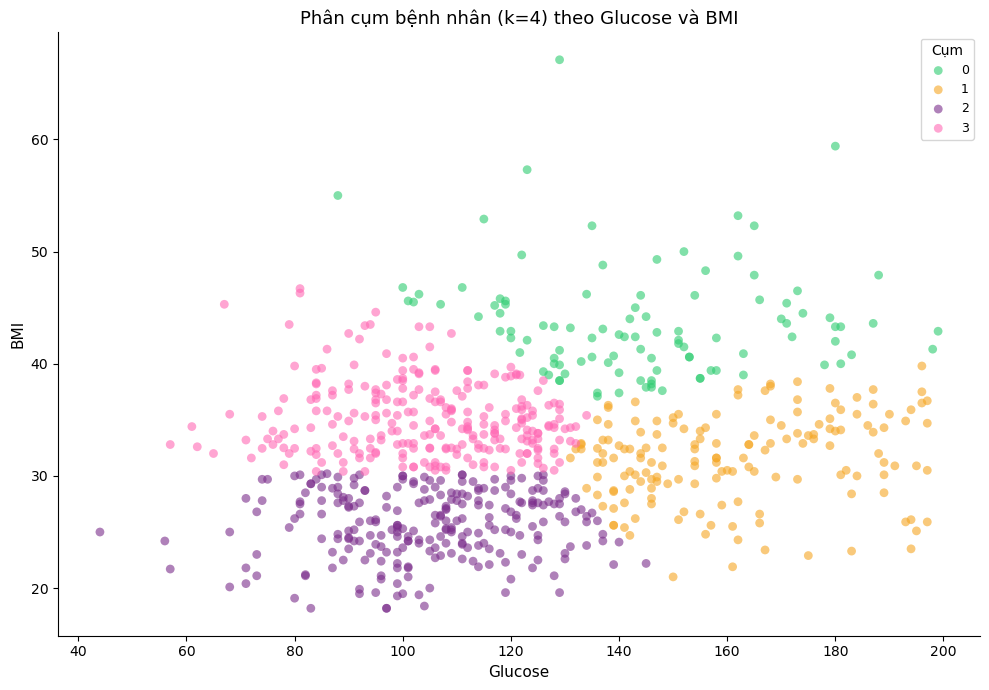

In [29]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Lấy 2 cột Glucose và BMI
X_cluster = df[['Glucose', 'BMI']].dropna()

# Chuẩn hóa trước khi clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# K-means k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
X_cluster['Cum'] = kmeans.fit_predict(X_scaled)

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 7))

colors = {0: '#2ecc71', 1: '#F5A623', 2: '#7B2D8B', 3: '#FF69B4'}

for cum, group in X_cluster.groupby('Cum'):
    ax.scatter(group['Glucose'], group['BMI'],
               color=colors[cum], label=str(cum),
               alpha=0.6, s=40, edgecolors='none')

ax.set_title("Phân cụm bệnh nhân (k=4) theo Glucose và BMI", fontsize=13)
ax.set_xlabel("Glucose", fontsize=11)
ax.set_ylabel("BMI", fontsize=11)
ax.legend(title='Cụm', fontsize=9, title_fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Biểu đồ C-square

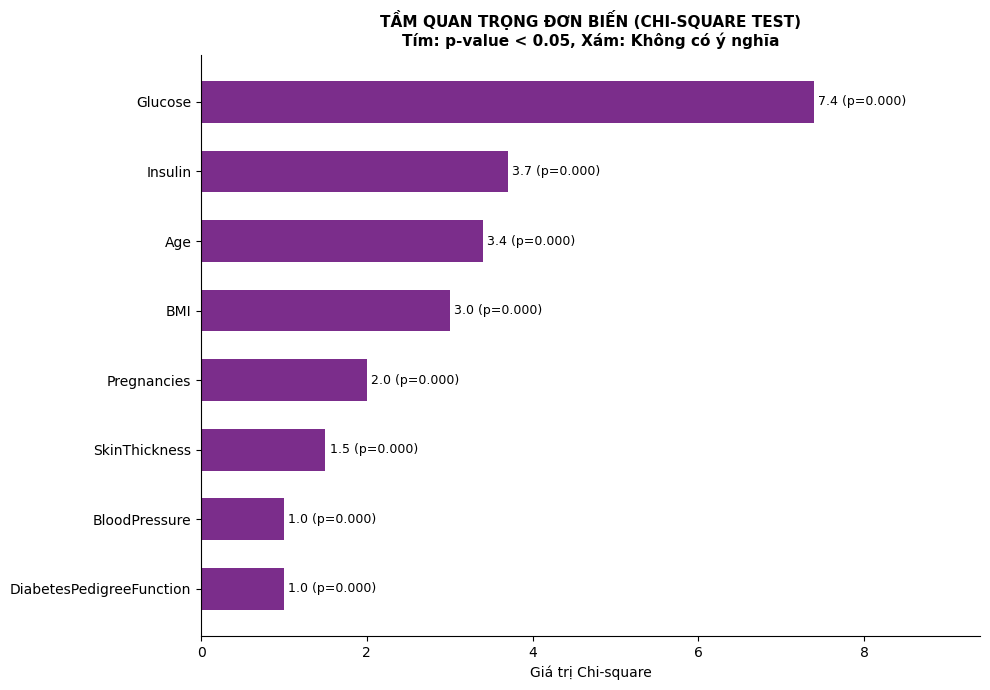

In [3]:
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import pandas as pd

cols = ['Glucose', 'Age', 'Pregnancies', 'BMI',
        'DiabetesPedigreeFunction', 'Insulin', 'SkinThickness', 'BloodPressure']

chi2_results = []
for col in cols:
    groups = pd.qcut(df[col], q=4, duplicates='drop')
    table = pd.crosstab(groups, df['Outcome'])
    chi2, p, dof, _ = chi2_contingency(table)
    chi2_norm = round((chi2 / len(df)) * 100 / dof, 1)
    chi2_results.append({'col': col, 'chi2': chi2_norm, 'p': p})

results = pd.DataFrame(chi2_results).sort_values('chi2', ascending=True)

# Có ý nghĩa → tím, không có ý nghĩa → xám
colors = ['#7B2D8B' if p < 0.05 else '#AAAAAA' for p in results['p']]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(results['col'], results['chi2'],
               color=colors, edgecolor='none', height=0.6)

for bar, (_, row) in zip(bars, results.iterrows()):
    p_text = f"p=0.000" if row['p'] < 0.001 else f"p={row['p']:.3f}"
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{row['chi2']} ({p_text})",
            va='center', fontsize=9)

ax.set_title("TẦM QUAN TRỌNG ĐƠN BIẾN (CHI-SQUARE TEST)\nTím: p-value < 0.05, Xám: Không có ý nghĩa",
             fontsize=11, fontweight='bold')
ax.set_xlabel("Giá trị Chi-square", fontsize=10)
ax.set_xlim(0, results['chi2'].max() + 2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Biểu đồ random Forest

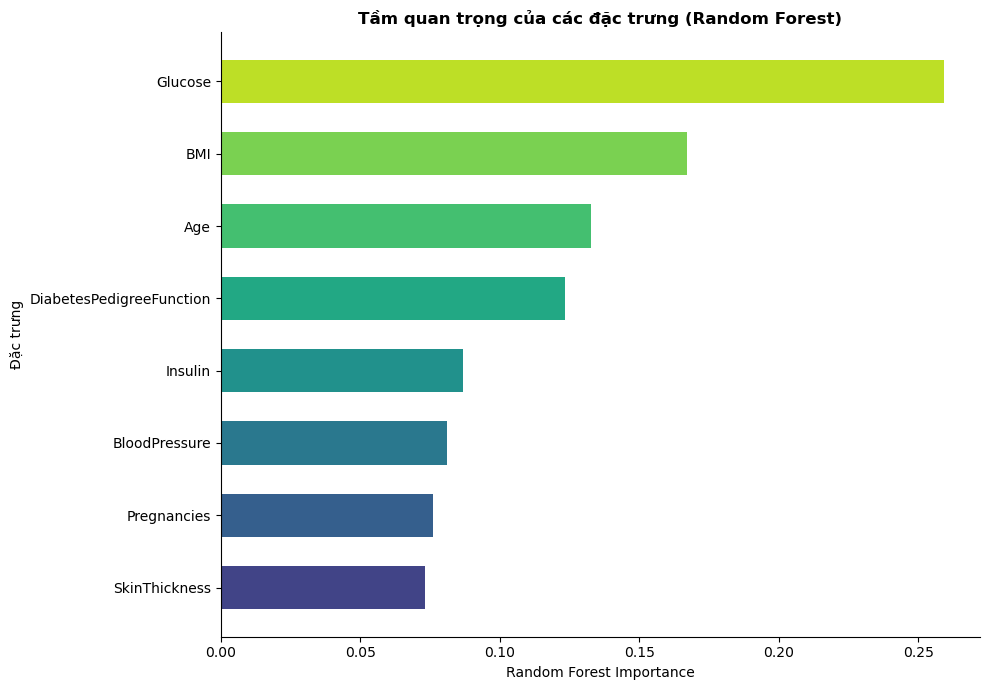

In [4]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# Chuẩn bị dữ liệu
cols = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction',
        'BloodPressure', 'Pregnancies', 'Insulin', 'SkinThickness']

X = df[cols].fillna(df[cols].mean())
y = df['Outcome']

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Lấy feature importance
importance_df = pd.DataFrame({
    'col': cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

# Màu gradient từ vàng xanh → tím
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(importance_df)))

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(importance_df['col'], importance_df['importance'],
               color=colors, edgecolor='none', height=0.6)

ax.set_title("Tầm quan trọng của các đặc trưng (Random Forest)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Random Forest Importance", fontsize=10)
ax.set_ylabel("Đặc trưng", fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Biểu đồ phương sai VIF

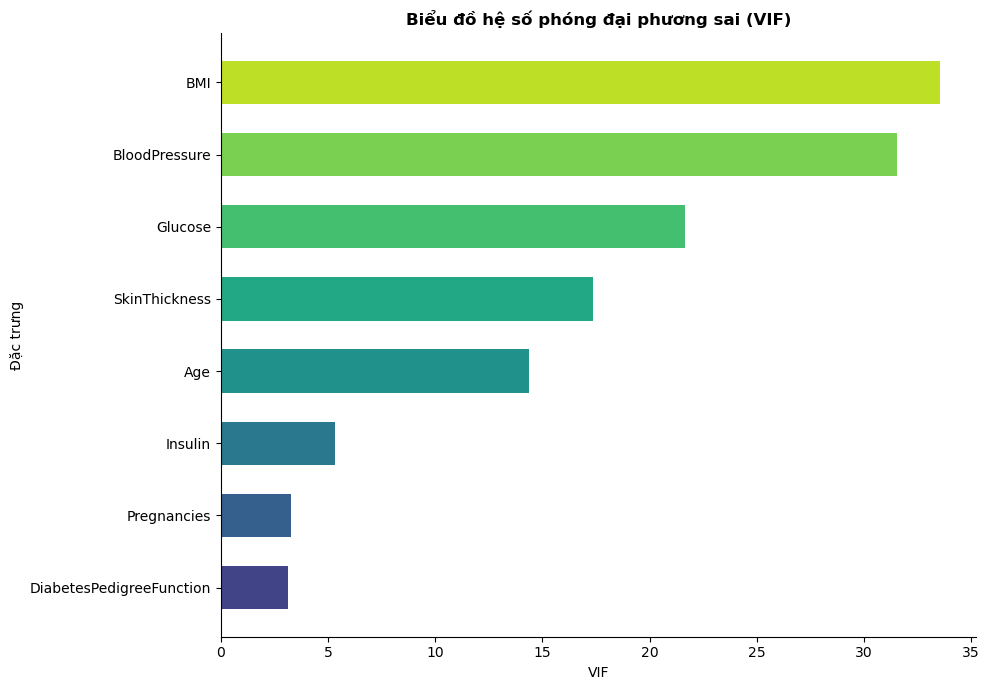

In [5]:
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Chuẩn bị dữ liệu
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X = df[cols].fillna(df[cols].mean())

# Tính VIF
vif_data = pd.DataFrame({
    'col': cols,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values('VIF', ascending=True)

# Màu gradient viridis
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(vif_data)))

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(vif_data['col'], vif_data['VIF'],
        color=colors, edgecolor='none', height=0.6)

ax.set_title("Biểu đồ hệ số phóng đại phương sai (VIF)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("VIF", fontsize=10)
ax.set_ylabel("Đặc trưng", fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Dặc điểm của từng cụm

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


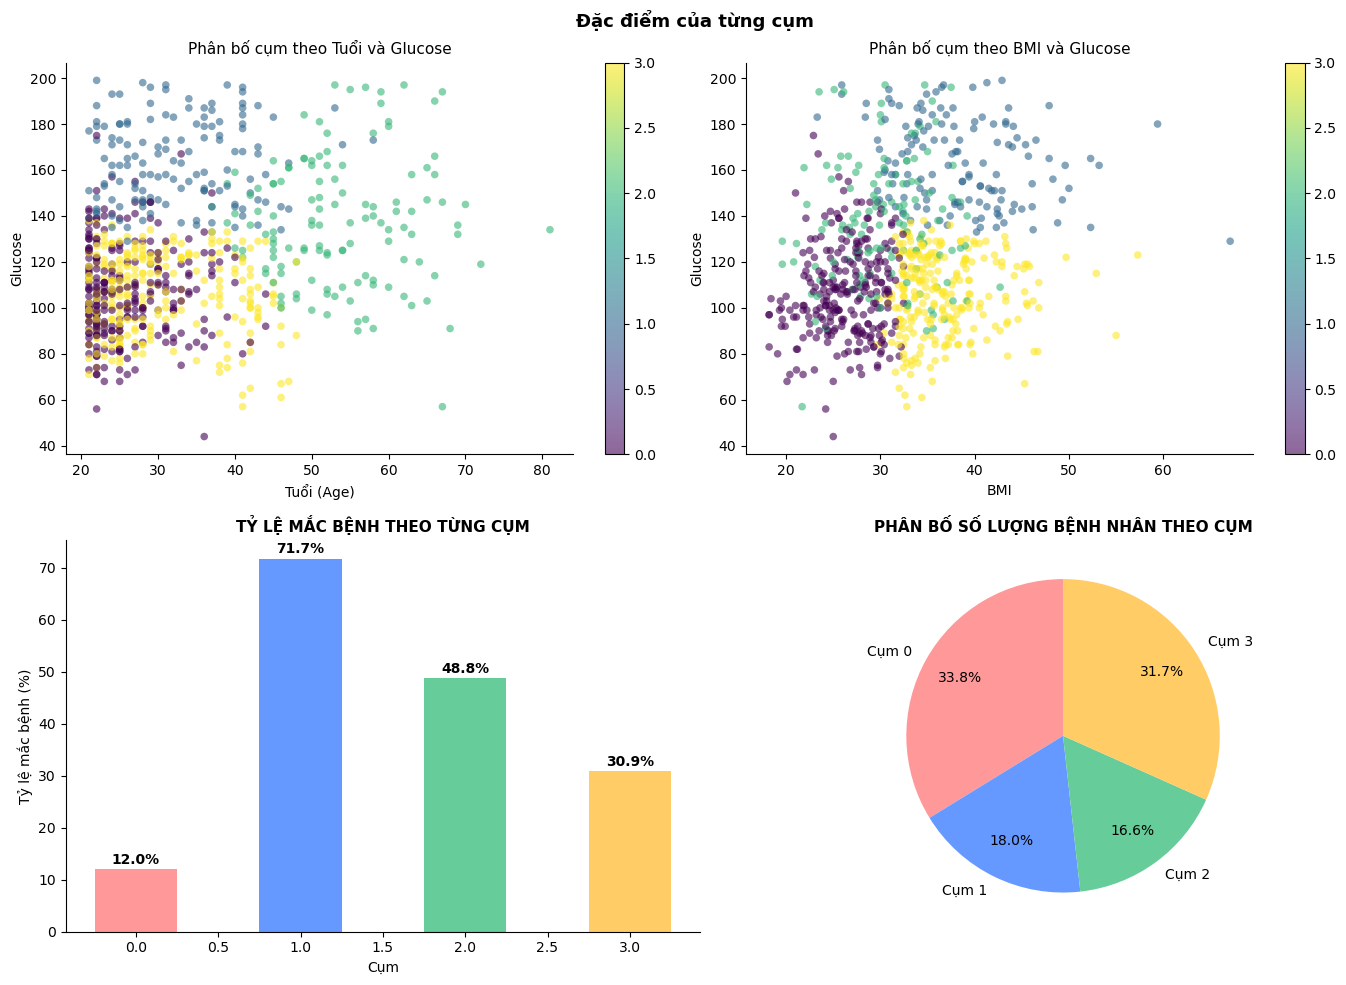

In [34]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np


# Chuẩn bị dữ liệu
X_cluster = df[['Glucose', 'BMI', 'Age']].dropna().copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# K-means k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
X_cluster['Cum'] = kmeans.fit_predict(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cmap = 'viridis'

# -----------------------
# Biểu đồ 1: Scatter Tuổi vs Glucose theo cụm
# -----------------------
sc1 = axes[0, 0].scatter(X_cluster['Age'], X_cluster['Glucose'],
                          c=X_cluster['Cum'], cmap=cmap,
                          alpha=0.6, s=30, edgecolors='none')
plt.colorbar(sc1, ax=axes[0, 0])
axes[0, 0].set_title("Phân bố cụm theo Tuổi và Glucose", fontsize=11)
axes[0, 0].set_xlabel("Tuổi (Age)", fontsize=10)
axes[0, 0].set_ylabel("Glucose", fontsize=10)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 2: Scatter BMI vs Glucose theo cụm
# -----------------------
sc2 = axes[0, 1].scatter(X_cluster['BMI'], X_cluster['Glucose'],
                          c=X_cluster['Cum'], cmap=cmap,
                          alpha=0.6, s=30, edgecolors='none')
plt.colorbar(sc2, ax=axes[0, 1])
axes[0, 1].set_title("Phân bố cụm theo BMI và Glucose", fontsize=11)
axes[0, 1].set_xlabel("BMI", fontsize=10)
axes[0, 1].set_ylabel("Glucose", fontsize=10)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 3: Bar chart tỷ lệ mắc bệnh theo cụm
# -----------------------
cum_outcome = X_cluster.copy()
cum_outcome['Outcome'] = df.loc[X_cluster.index, 'Outcome'].values
disease_rate = cum_outcome.groupby('Cum')['Outcome'].mean() * 100

bar_colors = ['#FF9999', '#6699FF', '#66CC99', '#FFCC66']
bars = axes[1, 0].bar(disease_rate.index, disease_rate.values,
                       color=bar_colors, width=0.5, edgecolor='none')

for bar, rate in zip(bars, disease_rate.values):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1,
                    f'{rate:.1f}%', ha='center', fontsize=10, fontweight='bold')

axes[1, 0].set_title("TỶ LỆ MẮC BỆNH THEO TỪNG CỤM", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Cụm", fontsize=10)
axes[1, 0].set_ylabel("Tỷ lệ mắc bệnh (%)", fontsize=10)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# -----------------------
# Biểu đồ 4: Pie chart số lượng bệnh nhân theo cụm
# -----------------------
cum_counts = X_cluster['Cum'].value_counts().sort_index()
pie_colors = ['#FF9999', '#6699FF', '#66CC99', '#FFCC66']
pie_labels = [f'Cụm {i}' for i in cum_counts.index]

axes[1, 1].pie(cum_counts.values, labels=pie_labels,
               colors=pie_colors, autopct='%1.1f%%',
               startangle=90, pctdistance=0.75)
axes[1, 1].set_title("PHÂN BỐ SỐ LƯỢNG BỆNH NHÂN THEO CỤM",
                      fontsize=11, fontweight='bold')

plt.suptitle("Đặc điểm của từng cụm", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()